In [1]:
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import h5py

# from scipy.stats import binned_statistic_2d
# from scipy.ndimage import gaussian_filter
from matplotlib.colors import LogNorm
from matplotlib.colors import SymLogNorm
import matplotlib
import matplotlib.cm as cm

# from abacusnbody.analysis.tsc import tsc_parallel
import time

from astropy.cosmology import FlatLambdaCDM
import astropy.units as u

# Import packages

sys.path.append('../src/')
# from filter_utils import *
# from SZstacker import SZMapStacker # type: ignore
from utils import ksz_from_delta_sigma, arcmin_to_comoving, comoving_to_arcmin, mass_to_temp

from stacker import SimulationStacker

import illustris_python as il

import yaml
import argparse
from pathlib import Path
import matplotlib.cm as cm
from matplotlib.lines import Line2D

import datetime
now = datetime.datetime.now()
FIG_SAVE_DIR = (
        Path('/pscratch/sd/l/lindajin/SimulationStacker/figures/')
        / now.strftime("%Y-%m")
        / now.strftime("%m-%d")
    )
FIG_SAVE_DIR.mkdir(parents=True, exist_ok=True)

# Create colormap for number density
colourmap = cm.twilight_r

DATA_DIR = '/pscratch/sd/l/lindajin/DH_profile_kSZ_WL/data/'
# Figure size parameters for consistent sizing across all plots
FIG_WIDTH_SINGLE = 11  # Width for single panel plots
FIG_WIDTH_DOUBLE = 20  # Width for 2-column plots
FIG_WIDTH_GRID = 16    # Width for grid layouts
FIG_DPI = 150          # Display DPI
FIG_SAVE_DPI = 200     # Saved figure DPI

# ===== Publication-Ready Figure Settings =====
# Set publication-quality defaults for all matplotlib figures
# Figure size parameters for consistent sizing across all plots
matplotlib.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Computer Modern", "CMU Serif", "DejaVu Serif", "Times New Roman"],
    "text.usetex": False,   # latex not available on compute nodes; use matplotlib mathtext
    "mathtext.fontset": "cm",
    "font.size": 18,
    "axes.titlesize": 18,
    "axes.labelsize": 18,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 14,
        # Grid
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
    'axes.prop_cycle': plt.cycler('color', colourmap(np.linspace(0.25, 0.95, 5))),

})



In [ ]:
NAME_EXTRA = '_sixth_gen_makeMap' 
## 4->5 
# instead of previous subhalo masses, now using halo masses from abundance matching in stellar masses subhalos['SubhaloMassInRadType'][central_subhalo_ids,4]
# DSigma from makeField -> all makeMaps
## 5->6 
# using all bounded subhalo mass subhalos['SubhaloMassType'][central_subhalo_ids, 4]
# add extra redshift snapshot 082 (z=0.21)

In [3]:
import utils
import importlib
importlib.reload(utils)
from utils import ksz_from_delta_sigma, arcmin_to_comoving, comoving_to_arcmin, mass_to_temp


In [4]:
# Configuration parameters
sim_type = 'IllustrisTNG'
snapshot = 74
sim_name = 'L50n512_SB35'
n_sims = 1024
redshift = 0.47
fig_name = 'compare_data_ratio' + NAME_EXTRA

load_field = False
save_field = False
rad_distance = 1.0  # in arcmin
mask_haloes = False
mask_radii = 3.0  # Number of virial radii to mask out for haloes. In units of R200c

min_radius = 1/6
max_radius = 6.0
num_radii = 15

projection = 'xy'  # 'xy', 'xz', 'yz'

### Profile parameters
pixel_size = 0.5  # in arcmin
filter_type = 'CAP'  # Options: 'CAP', 'cumulative', 'DSigma'
particle_type = 'tau'

n_pixels = 1000
filter_type_2 = 'DSigma'  # Options: 'CAP', 'cumulative', 'DSigma'
particle_type_2 = 'total'

### Physical parameters
number_densities = [1.0e-4, 2.8e-4, 5e-4, 1.0e-3, 2.4e-3]

# Volume of the simulation box
box_volume = 50**3  # (Mpc/h)^3

# Number densities to plot
number_densities_to_plot = [1.0e-4, 2.8e-4, 5e-4, 1.0e-3, 2.4e-3]

nd_labels = [
    r'$n = 1.0 \times 10^{-4}$ (Mpc$/h)^{-3}$',
    r'$n = 2.8 \times 10^{-4}$ (Mpc$/h)^{-3}$',
    r'$n = 5.0 \times 10^{-4}$ (Mpc$/h)^{-3}$',
    r'$n = 1.0 \times 10^{-3}$ (Mpc$/h)^{-3}$',
    r'$n = 2.4 \times 10^{-3}$ (Mpc$/h)^{-3}$'
]

# Calculate number of halos for each density
n_halos_per_density = [int(nd * box_volume) for nd in number_densities_to_plot]
print("Number of halos for each density:", n_halos_per_density)


base_path_template = '/pscratch/sd/l/lindajin/CAMELS/IllustrisTNG/L50n512_SB35/SB35_{}/data/'


Number of halos for each density: [12, 35, 62, 125, 300]


In [5]:
  
profile_file = base_path_template.format(0) + 'Profiles_tau-CAP_total-DSigma_ionized_gas-DSigma.npz'
profiles_loaded = np.load(profile_file)

for key in profiles_loaded.keys():
    print(f"  {key}")  

  prof0_tau_CAP_xy
  prof1_total_DSigma_arcmin2_xy
  prof1_total_DSigma_kpch2_xy
  prof2_ionized_gas_DSigma_arcmin2_xy
  prof2_ionized_gas_DSigma_kpch2_xy
  prof0_tau_CAP_xz
  prof1_total_DSigma_arcmin2_xz
  prof1_total_DSigma_kpch2_xz
  prof2_ionized_gas_DSigma_arcmin2_xz
  prof2_ionized_gas_DSigma_kpch2_xz
  prof0_tau_CAP_yz
  prof1_total_DSigma_arcmin2_yz
  prof1_total_DSigma_kpch2_yz
  prof2_ionized_gas_DSigma_arcmin2_yz
  prof2_ionized_gas_DSigma_kpch2_yz
  r0_arcmin
  r0_to_mpch
  r12_arcmin
  r12_to_mpch
  halo_masses
  number_density
  nPixels01
  pixelSize01
  methods01
  units01
  fb
  HubbleParam


# Profiles

In [19]:

ksz_profiles_xy_all_sims = []
delta_sigma_xy_profiles_all_sims = []
delta_sigma_ionized_xy_profiles_all_sims = []
ksz_profiles_xz_all_sims = []
delta_sigma_xz_profiles_all_sims = []
delta_sigma_ionized_xz_profiles_all_sims = []
ksz_profiles_yz_all_sims = []
delta_sigma_yz_profiles_all_sims = []
delta_sigma_ionized_yz_profiles_all_sims = []
delta_sigma_arcmin_xy_profiles_all_sims = []
delta_sigma_arcmin_xz_profiles_all_sims = []
delta_sigma_arcmin_yz_profiles_all_sims = []
delta_sigma_ionized_arcmin_xy_profiles_all_sims = []
delta_sigma_ionized_arcmin_xz_profiles_all_sims = []
delta_sigma_ionized_arcmin_yz_profiles_all_sims = []
fb_all_sims = []
h_all_sims = []
mass_all_sims = []


r0_arcmin_all_sims = []
r0_mpch_all_sims = []
r1_mpch_all_sims = []
r1_arcmin_all_sims =[]


for sim_id in np.arange(1024):
    profile_file = base_path_template.format(sim_id) + 'Profiles_tau-CAP_total-DSigma_ionized_gas-DSigma.npz'
    profiles_loaded = np.load(profile_file)

    ksz_profiles_xy_all_sims.append(profiles_loaded['prof0_tau_CAP_xy'])
    delta_sigma_xy_profiles_all_sims.append(profiles_loaded['prof1_total_DSigma_kpch2_xy'])
    delta_sigma_arcmin_xy_profiles_all_sims.append(profiles_loaded['prof1_total_DSigma_arcmin2_xy'])
    delta_sigma_ionized_arcmin_xy_profiles_all_sims.append(profiles_loaded['prof2_ionized_gas_DSigma_arcmin2_xy'])

    ksz_profiles_xz_all_sims.append(profiles_loaded['prof0_tau_CAP_xz'])
    delta_sigma_xz_profiles_all_sims.append(profiles_loaded['prof1_total_DSigma_kpch2_xz'])
    delta_sigma_arcmin_xz_profiles_all_sims.append(profiles_loaded['prof1_total_DSigma_arcmin2_xz'])
    delta_sigma_ionized_arcmin_xz_profiles_all_sims.append(profiles_loaded['prof2_ionized_gas_DSigma_arcmin2_xz'])

    ksz_profiles_yz_all_sims.append(profiles_loaded['prof0_tau_CAP_yz'])
    delta_sigma_yz_profiles_all_sims.append(profiles_loaded['prof1_total_DSigma_kpch2_yz'])
    delta_sigma_arcmin_yz_profiles_all_sims.append(profiles_loaded['prof1_total_DSigma_arcmin2_yz'])
    delta_sigma_ionized_arcmin_yz_profiles_all_sims.append(profiles_loaded['prof2_ionized_gas_DSigma_arcmin2_yz'])

    delta_sigma_ionized_xy_profiles_all_sims.append(profiles_loaded['prof2_ionized_gas_DSigma_kpch2_xy'])
    delta_sigma_ionized_xz_profiles_all_sims.append(profiles_loaded['prof2_ionized_gas_DSigma_kpch2_xz'])
    delta_sigma_ionized_yz_profiles_all_sims.append(profiles_loaded['prof2_ionized_gas_DSigma_kpch2_yz'])

    r0_arcmin = profiles_loaded['r0_arcmin']
    r1_mpch = profiles_loaded['r12_to_mpch']
    
    r0_arcmin_all_sims.append(r0_arcmin)
    r0_mpch_all_sims.append(profiles_loaded['r0_to_mpch'])
    r1_mpch_all_sims.append(r1_mpch)
    r1_arcmin_all_sims.append(profiles_loaded['r12_arcmin'])
    
    fb_all_sims.append(profiles_loaded['fb'])
    h_all_sims.append(profiles_loaded['HubbleParam'])

    # Get halo masses and compute log10(M_sun/h)
    halo_masses = profiles_loaded['halo_masses']
    mass_all_sims.append(halo_masses)

print(f"\nLoaded profiles for all projection from {len(ksz_profiles_xy_all_sims)} simulations")



Loaded profiles for all projection from 1024 simulations


In [8]:
for nd_idx, n_halos in enumerate(n_halos_per_density):
    # Collect profiles from all simulations for this number density
    all_profiles_this_nd = []
    all_std_this_nd = []

    all_profiles2_this_nd = []
    all_std2_this_nd = []
    
    for sim_id in range(len(delta_sigma_xy_profiles_all_sims)):
        profiles_xy = delta_sigma_arcmin_xy_profiles_all_sims[sim_id][:, :n_halos]
        profiles_xz = delta_sigma_arcmin_xz_profiles_all_sims[sim_id][:, :n_halos]
        profiles_yz = delta_sigma_arcmin_yz_profiles_all_sims[sim_id][:, :n_halos]
        profiles_this_nd = np.concatenate([profiles_xy, profiles_xz, profiles_yz], axis=1)
        all_profiles_this_nd.append(profiles_this_nd.mean(axis=1))
        all_std_this_nd.append(profiles_this_nd.std(axis=1))
        
        profiles_xy = delta_sigma_ionized_arcmin_xy_profiles_all_sims[sim_id][:, :n_halos]
        profiles_xz = delta_sigma_ionized_arcmin_xz_profiles_all_sims[sim_id][:, :n_halos]
        profiles_yz = delta_sigma_ionized_arcmin_yz_profiles_all_sims[sim_id][:, :n_halos]
        profiles_this_nd = np.concatenate([profiles_xy, profiles_xz, profiles_yz], axis=1)
        all_profiles2_this_nd.append(profiles_this_nd.mean(axis=1))
        all_std2_this_nd.append(profiles_this_nd.std(axis=1))
        
    all_profiles_this_nd = np.array(all_profiles_this_nd)
    all_std_this_nd = np.array(all_std_this_nd)
    all_profiles2_this_nd = np.array(all_profiles2_this_nd)
    all_std2_this_nd = np.array(all_std2_this_nd)
    mean_halo_mass_this_nd = np.array(mass_all_sims)[:, :n_halos].mean()  # Mean halo mass for this number density
    
    if len(all_profiles_this_nd) > 0:
        save_filename = DATA_DIR + NAME_EXTRA + f'mean_DeltaSigma_total_profiles_arcmin_nd_{nd_idx}_n_{n_halos}.npz'
        np.savez(save_filename,
                prof=all_profiles_this_nd * 1e-6,  # Convert from kpc^-2 to pc^-2,
                prof_std=all_std_this_nd * 1e-6,
                radii=r1_arcmin_all_sims,  
                number_density=number_densities_to_plot[nd_idx],
                n_halos=n_halos,
                nd_label=nd_labels[nd_idx]+rf' $\rm log(\langle M_{{\rm 500}}[M_\odot/h] \rangle)={np.log10(mean_halo_mass_this_nd):.2f}$')
        print(f"Saved profiles for number density {nd_idx} to {save_filename}")

        save_filename = DATA_DIR + NAME_EXTRA + f'mean_DeltaSigma_ionized_profiles_arcmin_nd_{nd_idx}_n_{n_halos}.npz'
        np.savez(save_filename,
                prof=all_profiles2_this_nd * 1e-6,  # Convert from kpc^-2 to pc^-2,
                prof_std=all_std2_this_nd * 1e-6,
                radii=r1_arcmin_all_sims,  
                number_density=number_densities_to_plot[nd_idx],
                n_halos=n_halos,
                nd_label=nd_labels[nd_idx]+rf' $\rm log(\langle M_{{\rm 500}}[M_\odot/h] \rangle)={np.log10(mean_halo_mass_this_nd):.2f}$')
        print(f"Saved profiles for number density {nd_idx} to {save_filename}")

Saved profiles for number density 0 to /pscratch/sd/l/lindajin/DH_profile_kSZ_WL/data/_fifth_gen_makeMapmean_DeltaSigma_total_profiles_arcmin_nd_0_n_12.npz
Saved profiles for number density 0 to /pscratch/sd/l/lindajin/DH_profile_kSZ_WL/data/_fifth_gen_makeMapmean_DeltaSigma_ionized_profiles_arcmin_nd_0_n_12.npz
Saved profiles for number density 1 to /pscratch/sd/l/lindajin/DH_profile_kSZ_WL/data/_fifth_gen_makeMapmean_DeltaSigma_total_profiles_arcmin_nd_1_n_35.npz
Saved profiles for number density 1 to /pscratch/sd/l/lindajin/DH_profile_kSZ_WL/data/_fifth_gen_makeMapmean_DeltaSigma_ionized_profiles_arcmin_nd_1_n_35.npz


Saved profiles for number density 2 to /pscratch/sd/l/lindajin/DH_profile_kSZ_WL/data/_fifth_gen_makeMapmean_DeltaSigma_total_profiles_arcmin_nd_2_n_62.npz
Saved profiles for number density 2 to /pscratch/sd/l/lindajin/DH_profile_kSZ_WL/data/_fifth_gen_makeMapmean_DeltaSigma_ionized_profiles_arcmin_nd_2_n_62.npz
Saved profiles for number density 3 to /pscratch/sd/l/lindajin/DH_profile_kSZ_WL/data/_fifth_gen_makeMapmean_DeltaSigma_total_profiles_arcmin_nd_3_n_125.npz
Saved profiles for number density 3 to /pscratch/sd/l/lindajin/DH_profile_kSZ_WL/data/_fifth_gen_makeMapmean_DeltaSigma_ionized_profiles_arcmin_nd_3_n_125.npz
Saved profiles for number density 4 to /pscratch/sd/l/lindajin/DH_profile_kSZ_WL/data/_fifth_gen_makeMapmean_DeltaSigma_total_profiles_arcmin_nd_4_n_300.npz
Saved profiles for number density 4 to /pscratch/sd/l/lindajin/DH_profile_kSZ_WL/data/_fifth_gen_makeMapmean_DeltaSigma_ionized_profiles_arcmin_nd_4_n_300.npz


In [9]:
# Read HSC lensing data for LRG_bin1
from astropy.io import fits
import glob

# Path to lensing measurements
lensing_path = '/pscratch/sd/r/rhliu/public/lensing_measurements/'

# Find all files for LRG_bin1
lrg_bin1_files = sorted(glob.glob(lensing_path + 'dsigma_tomo_noboost_hscy3_*_LRG_bin1.fits'))

print(f"Found {len(lrg_bin1_files)} files for LRG_bin1:")
for f in lrg_bin1_files:
    print(f"  {f.split('/')[-1]}")

# Read the data from each file
hsc_lensing_data = {}
for filepath in lrg_bin1_files:
    filename = filepath.split('/')[-1]
    # Extract HSC bin number from filename
    hsc_bin = filename.split('_bin')[1].split('_')[0]
    
    with fits.open(filepath) as hdu:
        data = hdu[1].data
        
        
        hsc_lensing_data[f'hscy3_bin{hsc_bin}'] = {
            'rp': data['rp'],  # projected radius [Mpc/h]
            'rp_min': data['rp_min'],  # bin minimum [Mpc/h]
            'rp_max': data['rp_max'],  # bin maximum [Mpc/h]
            'ds': data['ds'],  # Delta Sigma
            'ds_err': data['ds_err'],  # Delta Sigma error
            'ds_raw': data['ds_raw'],  # raw Delta Sigma
            'ds_r': data['ds_r'],  # random-subtracted Delta Sigma
            'z_l': data['z_l'],  # lens redshift
            'z_s': data['z_s'],  # source redshift
            'n_pairs': data['n_pairs'],  # number of pairs
            '1+m': data['1+m'],  # multiplicative bias correction
            '2R': data['2R'],  # boost factor
            'cov': data['cov'],  # covariance matrix
        }
    
    print(f"\nLoaded {filename}:")
    print(f"  Radial bins: {len(data['rp'])}")
    print(f"  Radial range: {data['rp'].min():.3f} - {data['rp'].max():.3f} Mpc")
    print(f"  Lens redshift: {data['z_l'][0]:.3f}")
    print(f"  Source redshift: {data['z_s'][0]:.3f}")

print(f"\nData stored in HSC dictionary with keys: {list(hsc_lensing_data.keys())}")

DESI_data = np.load('Fig1_Fig8_dr10_allfoot_perbin_sigmaz0.0500_dr6_corr_pzbin1.npz')
print(f"\nData stored in DESI dictionary with keys: {list(DESI_data.keys())}")

r_v_sims = np.load(DATA_DIR+'r_v_sims.npy')



Found 3 files for LRG_bin1:
  dsigma_tomo_noboost_hscy3_bin2_LRG_bin1.fits
  dsigma_tomo_noboost_hscy3_bin3_LRG_bin1.fits
  dsigma_tomo_noboost_hscy3_bin4_LRG_bin1.fits

Loaded dsigma_tomo_noboost_hscy3_bin2_LRG_bin1.fits:
  Radial bins: 9
  Radial range: 0.390 - 2.338 Mpc
  Lens redshift: 0.413
  Source redshift: 0.775

Loaded dsigma_tomo_noboost_hscy3_bin3_LRG_bin1.fits:
  Radial bins: 9
  Radial range: 0.390 - 2.338 Mpc
  Lens redshift: 0.500
  Source redshift: 1.121

Loaded dsigma_tomo_noboost_hscy3_bin4_LRG_bin1.fits:
  Radial bins: 9
  Radial range: 0.390 - 2.338 Mpc
  Lens redshift: 0.504
  Source redshift: 1.378

Data stored in HSC dictionary with keys: ['hscy3_bin2', 'hscy3_bin3', 'hscy3_bin4']

Data stored in DESI dictionary with keys: ['theta_arcmins', 'prof', 'cov']


# By Number density

## Profile

Number density 0: 1024 simulations × 3 projections × 12 halos
Saved profiles for number density 0 to /pscratch/sd/l/lindajin/DH_profile_kSZ_WL/data/mean_DeltaSigma_profiles_pc_nd_0_n_12.npz
Number density 1: 1024 simulations × 3 projections × 35 halos
Saved profiles for number density 1 to /pscratch/sd/l/lindajin/DH_profile_kSZ_WL/data/mean_DeltaSigma_profiles_pc_nd_1_n_35.npz
Number density 2: 1024 simulations × 3 projections × 62 halos
Saved profiles for number density 2 to /pscratch/sd/l/lindajin/DH_profile_kSZ_WL/data/mean_DeltaSigma_profiles_pc_nd_2_n_62.npz
Number density 3: 1024 simulations × 3 projections × 125 halos
Saved profiles for number density 3 to /pscratch/sd/l/lindajin/DH_profile_kSZ_WL/data/mean_DeltaSigma_profiles_pc_nd_3_n_125.npz
Number density 4: 1024 simulations × 3 projections × 300 halos
Saved profiles for number density 4 to /pscratch/sd/l/lindajin/DH_profile_kSZ_WL/data/mean_DeltaSigma_profiles_pc_nd_4_n_300.npz


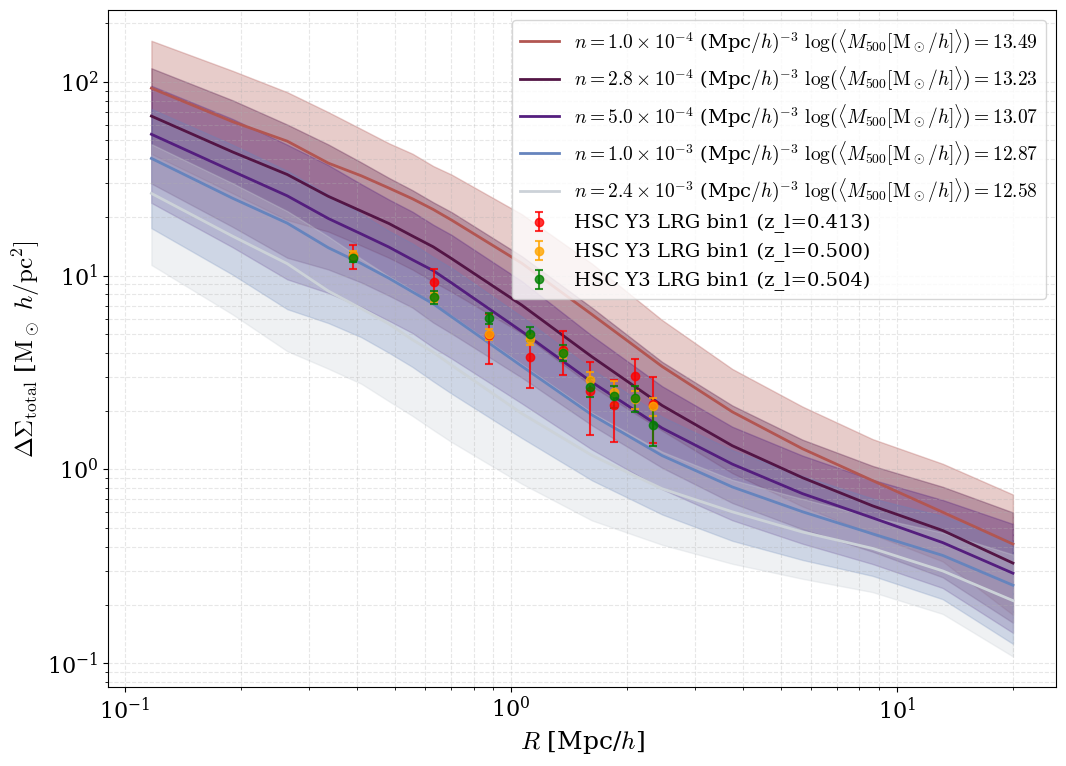

In [10]:
# Extract colors from prop_cycle
prop_cycle = plt.rcParams['axes.prop_cycle']
cycle_colors = prop_cycle.by_key()['color']

# Get radial bins
radii = r1_mpch  # in Mpc/h

# Number density labels
nd_labels = [
    r'$n = 1.0 \times 10^{-4}$ (Mpc$/h)^{-3}$',
    r'$n = 2.8 \times 10^{-4}$ (Mpc$/h)^{-3}$',
    r'$n = 5.0 \times 10^{-4}$ (Mpc$/h)^{-3}$',
    r'$n = 1.0 \times 10^{-3}$ (Mpc$/h)^{-3}$',
    r'$n = 2.4 \times 10^{-3}$ (Mpc$/h)^{-3}$'
]
nd_colors = [cycle_colors[i] for i in range(5)]

fig, ax = plt.subplots(1, 1, figsize=(FIG_WIDTH_SINGLE, 8))

# For each number density
for nd_idx, (n_halos, nd_label) in enumerate(zip(n_halos_per_density, nd_labels)):
    # Collect profiles from all simulations for this number density
    all_profiles_this_nd = []
    all_std_this_nd = []
    
    for sim_id in range(len(delta_sigma_xy_profiles_all_sims)):
        # Select first n_halos (halos are already sorted by descending mass)
        # Collect profiles from all three projections
        profiles_xy = delta_sigma_xy_profiles_all_sims[sim_id][:, :n_halos]
        profiles_xz = delta_sigma_xz_profiles_all_sims[sim_id][:, :n_halos]
        profiles_yz = delta_sigma_yz_profiles_all_sims[sim_id][:, :n_halos]
        
        # Concatenate along the halo dimension
        profiles_this_nd = np.concatenate([profiles_xy, profiles_xz, profiles_yz], axis=1)
        # Take mean and std across halos for each simulation
        all_profiles_this_nd.append(profiles_this_nd.mean(axis=1))
        all_std_this_nd.append(profiles_this_nd.std(axis=1))
        
    all_profiles_this_nd = np.array(all_profiles_this_nd)
    all_std_this_nd = np.array(all_std_this_nd)
    mean_halo_mass_this_nd = np.array(mass_all_sims)[:, :n_halos].mean()

    
    if len(all_profiles_this_nd) > 0:
        # Convert to proper units
        all_profiles_concatenated = all_profiles_this_nd * 1e-6  # Convert from kpc^-2 to pc^-2
        
        # Calculate median and percentiles across simulations
        median_profile = np.nanmedian(all_profiles_concatenated, axis=0)
        p16_profile = np.nanpercentile(all_profiles_concatenated, 16, axis=0)
        p84_profile = np.nanpercentile(all_profiles_concatenated, 84, axis=0)

        # Find the simulation whose mean profile is closest to the median
        # _profile_distances = np.array([np.nanmean(np.abs(m - median_profile)) for m in all_profiles_concatenated])
        # _closest_sim_idx = np.argmin(_profile_distances)
        # print(f"Profile for mean halo mass distance to median for number density {nd_idx}: {_profile_distances[_closest_sim_idx]}")
        # mean_halo_mass_this_nd = np.array(mass_all_sims)[_closest_sim_idx, :n_halos].mean()

        
        # Filter for r >= 0
        r_mask = radii[:len(median_profile)] >= 0
        
        # Plot median with shaded region
        ax.plot(radii[:len(median_profile)][r_mask], median_profile[r_mask], 
               color=nd_colors[nd_idx], linewidth=2, 
               label=nd_label+rf' $\log(\langle M_{{500}}[\rm M_\odot$$/h] \rangle)={np.log10(mean_halo_mass_this_nd):.2f}$')
        ax.fill_between(radii[:len(median_profile)][r_mask], 
                       p16_profile[r_mask], 
                       p84_profile[r_mask], 
                       color=nd_colors[nd_idx], alpha=0.3)
        
        print(f"Number density {nd_idx}: {all_profiles_concatenated.shape[0]} simulations × 3 projections × {n_halos} halos")

        save_filename = DATA_DIR + f'mean_DeltaSigma_profiles_pc_nd_{nd_idx}_n_{n_halos}.npz'
        np.savez(save_filename,
                prof=all_profiles_concatenated,
                prof_std=all_std_this_nd * 1e-6,
                radii=radii[:all_profiles_concatenated.shape[1]],
                number_density=number_densities_to_plot[nd_idx],
                n_halos=n_halos,
                nd_label=nd_label)
        print(f"Saved profiles for number density {nd_idx} to {save_filename}")

# Overplot HSC lensing data with error bars
# Cosmological parameters (assuming Planck cosmology with h ~ 0.676)
h = 0.676
hsc_markers = ['o', 's', '^']
hsc_colors_list = ['red', 'orange', 'green']

for idx, (key, marker, color) in enumerate(zip(['hscy3_bin2', 'hscy3_bin3', 'hscy3_bin4'], 
                                                 hsc_markers, hsc_colors_list)):
    if key in hsc_lensing_data:
        hsc_data = hsc_lensing_data[key]
        rp_h = hsc_data['rp'] 
        ds_h = hsc_data['ds'] 
        ds_err_h = hsc_data['ds_err'] 
        
        # Plot HSC data
        z_l = hsc_data['z_l'][0]
        ax.errorbar(rp_h, ds_h, yerr=ds_err_h, 
                   fmt='o', markersize=6, capsize=3, capthick=1.5,
                   color=color, ecolor=color, alpha=0.8,
                   label=f'HSC Y3 LRG bin1 (z_l={z_l:.3f})', zorder=10)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$R$ [Mpc/$h$]')
ax.set_ylabel(r'${\Delta \Sigma}_{\rm total}$ [$\rm M_\odot$ $h / \mathrm{pc}^2]$')
ax.legend(loc='upper right')
ax.grid(True, which='both')
# ax.set_xlim(0,2.5)
# ax.set_ylim(0, 200)
fig.tight_layout()
fig_name = 'mean_DeltaSigma_profiles_by_number_density'+NAME_EXTRA+'.pdf'
fig.savefig(FIG_SAVE_DIR / fig_name, bbox_inches='tight', dpi=FIG_SAVE_DPI)
plt.show()

Number of halos for each density: [12, 35, 62, 125, 300]
Number density 0: 17 total halo profiles (from 1024 sims × 3 projections × 12 halos)
Saved profiles for number density 0 to /pscratch/sd/l/lindajin/DH_profile_kSZ_WL/data/mean_R_DeltaSigma_profiles_nd_0_n_12.npz
Number density 1: 17 total halo profiles (from 1024 sims × 3 projections × 35 halos)
Saved profiles for number density 1 to /pscratch/sd/l/lindajin/DH_profile_kSZ_WL/data/mean_R_DeltaSigma_profiles_nd_1_n_35.npz
Number density 2: 17 total halo profiles (from 1024 sims × 3 projections × 62 halos)
Saved profiles for number density 2 to /pscratch/sd/l/lindajin/DH_profile_kSZ_WL/data/mean_R_DeltaSigma_profiles_nd_2_n_62.npz
Number density 3: 17 total halo profiles (from 1024 sims × 3 projections × 125 halos)
Saved profiles for number density 3 to /pscratch/sd/l/lindajin/DH_profile_kSZ_WL/data/mean_R_DeltaSigma_profiles_nd_3_n_125.npz
Number density 4: 17 total halo profiles (from 1024 sims × 3 projections × 300 halos)
Saved p

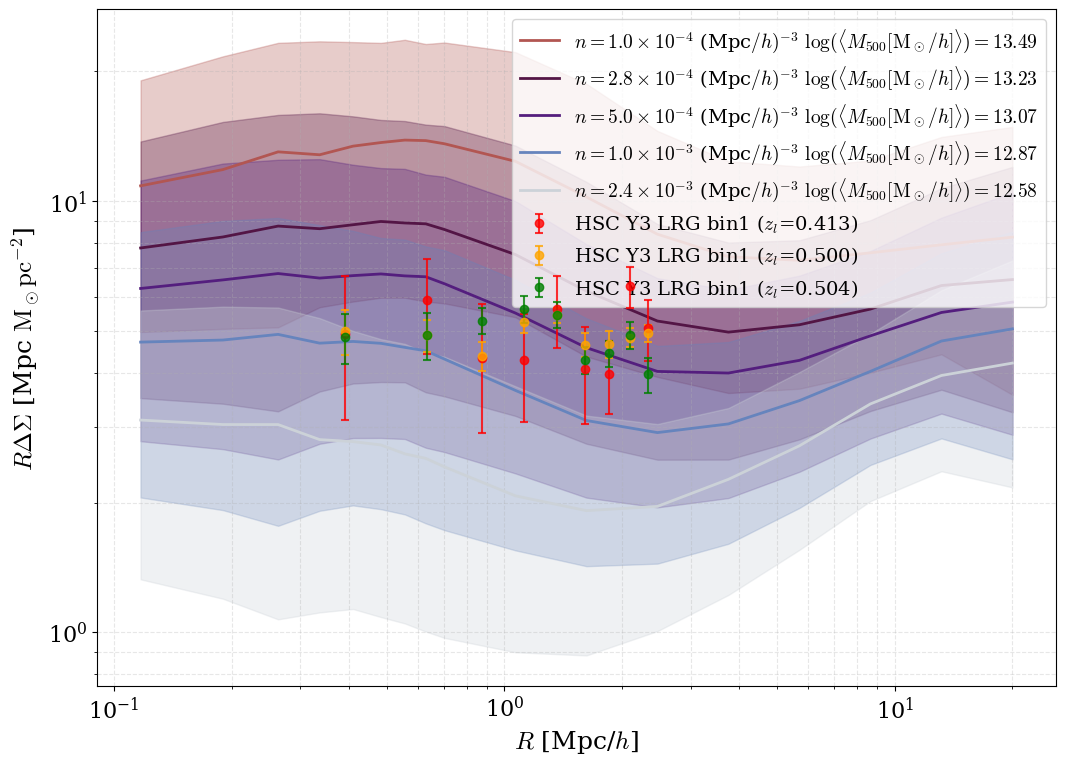

In [11]:
# Volume of the simulation box
box_volume = 50**3  # (Mpc/h)^3

# Number densities to plot
number_densities_to_plot = [1.0e-4, 2.8e-4, 5e-4, 1.0e-3, 2.4e-3]

# Calculate number of halos for each density
n_halos_per_density = [int(nd * box_volume) for nd in number_densities_to_plot]
print("Number of halos for each density:", n_halos_per_density)

# Extract colors from prop_cycle
prop_cycle = plt.rcParams['axes.prop_cycle']
cycle_colors = prop_cycle.by_key()['color']

# Get radial bins
radii = r1_mpch  # in Mpc/h

nd_colors = [cycle_colors[i] for i in range(5)]

fig, ax = plt.subplots(1, 1, figsize=(FIG_WIDTH_SINGLE, 8))

# For each number density
for nd_idx, (n_halos, nd_label) in enumerate(zip(n_halos_per_density, nd_labels)):
    # Collect profiles from all simulations for this number density
    all_profiles_this_nd = []
    all_std_this_nd = []

    for sim_id in range(len(delta_sigma_xy_profiles_all_sims)):
        # Select first n_halos (halos are already sorted by descending mass)
        # Collect profiles from all three projections
        profiles_xy = delta_sigma_xy_profiles_all_sims[sim_id][:, :n_halos]
        profiles_xz = delta_sigma_xz_profiles_all_sims[sim_id][:, :n_halos]
        profiles_yz = delta_sigma_yz_profiles_all_sims[sim_id][:, :n_halos]
        
        # Concatenate along the halo dimension
        profiles_this_nd = np.concatenate([profiles_xy, profiles_xz, profiles_yz], axis=1)
        all_profiles_this_nd.append(profiles_this_nd.mean(axis=1))
        all_std_this_nd.append(profiles_this_nd.std(axis=1))

    all_profiles_this_nd = np.array(all_profiles_this_nd)
    all_std_this_nd = np.array(all_std_this_nd)
    mean_halo_mass_this_nd = np.array(mass_all_sims)[:, :n_halos].mean()  # Mean halo mass for this number density

    if len(all_profiles_this_nd) > 0:
        # Concatenate all profiles across all simulations
        all_profiles_concatenated = all_profiles_this_nd #np.concatenate(all_profiles_this_nd, axis=1)
        all_profiles_concatenated *= 1e-6  # Convert from kpc^-2 to pc^-2
        
        # Calculate median and percentiles
        median_profile = np.nanmedian(all_profiles_concatenated, axis=0)
        p16_profile = np.nanpercentile(all_profiles_concatenated, 16, axis=0)
        p84_profile = np.nanpercentile(all_profiles_concatenated, 84, axis=0)
        
        median_profile *= radii[:len(median_profile)]
        p16_profile *= radii[:len(median_profile)]
        p84_profile *= radii[:len(median_profile)]

        
        # Plot median with shaded region
        ax.plot(radii[:len(median_profile)], median_profile, 
               color=nd_colors[nd_idx], linewidth=2, 
               label=nd_label+rf' $\log(\langle M_{{500}}[\rm M_\odot$$/h] \rangle)={np.log10(mean_halo_mass_this_nd):.2f}$')
        ax.fill_between(radii[:len(median_profile)], 
                       p16_profile, 
                       p84_profile, 
                       color=nd_colors[nd_idx], alpha=0.3)
        
        print(f"Number density {nd_idx}: {all_profiles_concatenated.shape[1]} total halo profiles (from {len(all_profiles_this_nd)} sims × 3 projections × {n_halos} halos)")
    
        save_filename = DATA_DIR + f'mean_R_DeltaSigma_profiles_nd_{nd_idx}_n_{n_halos}.npz'
        np.savez(save_filename,
                prof=all_profiles_concatenated,
                prof_std=all_std_this_nd,
                radii=radii[:all_profiles_concatenated.shape[0]],
                number_density=number_densities_to_plot[nd_idx],
                n_halos=n_halos,
                nd_label=nd_label)
        print(f"Saved profiles for number density {nd_idx} to {save_filename}")

h = 0.676
hsc_colors_list = ['red', 'orange', 'green']

for idx, (key, marker, color) in enumerate(zip(['hscy3_bin2', 'hscy3_bin3', 'hscy3_bin4'], 
                                                 hsc_markers, hsc_colors_list)):
    if key in hsc_lensing_data:
        hsc_data = hsc_lensing_data[key]
        rp_h = hsc_data['rp'] 
        ds_h = hsc_data['ds'] 
        ds_err_h = hsc_data['ds_err'] 
        
        # Plot HSC data
        z_l = hsc_data['z_l'][0]
        ax.errorbar(rp_h, ds_h*rp_h, yerr=ds_err_h, 
                   fmt='o', markersize=6, capsize=3, capthick=1.5,
                   color=color, ecolor=color, alpha=0.8,
                   label=rf'HSC Y3 LRG bin1 ($z_l$={z_l:.3f})', zorder=10)

ax.set_xscale('log')
ax.set_yscale('log')
# ax.set_xlim(rp_h.min()-0.1, rp_h.max()+0.5)
ax.set_xlabel(r'$R$ [Mpc/$h$]')
ax.set_ylabel(r'$R \Delta \Sigma$ [Mpc $\rm M_\odot {pc}^{-2}$]')
ax.legend(loc='upper right')
ax.grid(True, which='both')


fig.tight_layout()
fig_name = 'mean_R_DeltaSigma_profiles_by_number_density'+NAME_EXTRA+'.pdf'
fig.savefig(FIG_SAVE_DIR / fig_name, bbox_inches='tight', dpi=FIG_SAVE_DPI)
plt.show()

Number density 0: 1024 simulations × 3 projections × 12 halos
Saved profiles for number density 0 to /pscratch/sd/l/lindajin/DH_profile_kSZ_WL/data/mean_kSZ_profiles_nd_0_n_12.npz
Number density 1: 1024 simulations × 3 projections × 35 halos
Saved profiles for number density 1 to /pscratch/sd/l/lindajin/DH_profile_kSZ_WL/data/mean_kSZ_profiles_nd_1_n_35.npz
Number density 2: 1024 simulations × 3 projections × 62 halos
Saved profiles for number density 2 to /pscratch/sd/l/lindajin/DH_profile_kSZ_WL/data/mean_kSZ_profiles_nd_2_n_62.npz
Number density 3: 1024 simulations × 3 projections × 125 halos
Saved profiles for number density 3 to /pscratch/sd/l/lindajin/DH_profile_kSZ_WL/data/mean_kSZ_profiles_nd_3_n_125.npz
Number density 4: 1024 simulations × 3 projections × 300 halos
Saved profiles for number density 4 to /pscratch/sd/l/lindajin/DH_profile_kSZ_WL/data/mean_kSZ_profiles_nd_4_n_300.npz


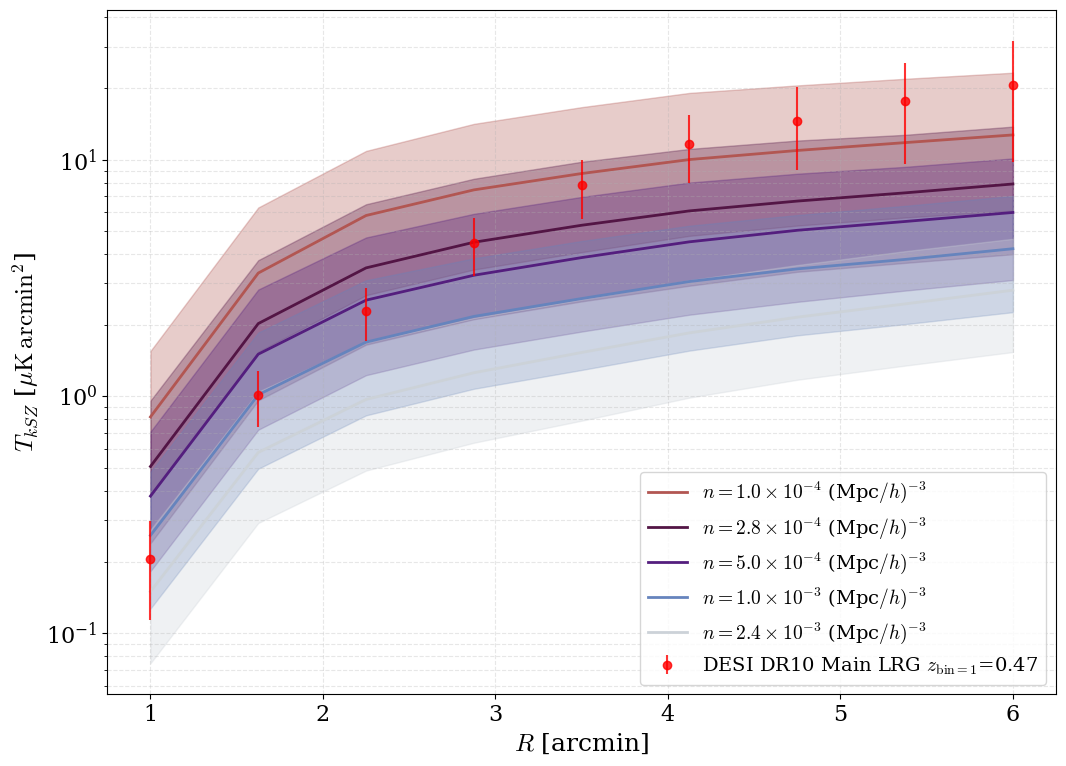

In [12]:
# T_kSZ profiles by number density

# Get radial bins

radii = r0_arcmin  # in arcmin



# Extract colors from prop_cycle

prop_cycle = plt.rcParams['axes.prop_cycle']

cycle_colors = prop_cycle.by_key()['color']



nd_colors = [cycle_colors[i] for i in range(5)]



fig, ax = plt.subplots(1, 1, figsize=(FIG_WIDTH_SINGLE, 8))



# For each number density

for nd_idx, (n_halos, nd_label) in enumerate(zip(n_halos_per_density, nd_labels)):

    # Collect profiles from all simulations for this number density

    all_profiles_this_nd = []

    all_std_this_nd = []

    

    for sim_id in range(len(ksz_profiles_xy_all_sims)):

        # Select first n_halos (halos are already sorted by descending mass)

        # Collect profiles from all three projections

        profiles_xy = ksz_profiles_xy_all_sims[sim_id][:, :n_halos]

        profiles_xz = ksz_profiles_xz_all_sims[sim_id][:, :n_halos]

        profiles_yz = ksz_profiles_yz_all_sims[sim_id][:, :n_halos]

        

        # Concatenate along the halo dimension

        profiles_this_nd = np.concatenate([profiles_xy, profiles_xz, profiles_yz], axis=1)

        all_profiles_this_nd.append(profiles_this_nd.mean(axis=1) / r_v_sims[sim_id])  # Take mean across halos for this sim and projection

        all_std_this_nd.append((profiles_this_nd / r_v_sims[sim_id]).std(axis=1))



    all_profiles_this_nd = np.array(all_profiles_this_nd)

    all_std_this_nd = np.array(all_std_this_nd)



    if len(all_profiles_this_nd) > 0:

        # Calculate median and percentiles

        median_profile = np.nanmedian(all_profiles_this_nd, axis=0)

        p16_profile = np.nanpercentile(all_profiles_this_nd, 16, axis=0)

        p84_profile = np.nanpercentile(all_profiles_this_nd, 84, axis=0)

        

        # Restrict to the plotted angular range

        r_mask = (radii[:len(median_profile)] >= 0.5) & (radii[:len(median_profile)] <= 6.0)

        

        # Plot median with shaded region

        ax.plot(radii[:len(median_profile)][r_mask], median_profile[r_mask], 

               color=nd_colors[nd_idx], linewidth=2, 

               label=nd_label)

        ax.fill_between(radii[:len(median_profile)][r_mask], 

                       p16_profile[r_mask], 

                       p84_profile[r_mask], 

                       color=nd_colors[nd_idx], alpha=0.3)

        

        print(f"Number density {nd_idx}: {all_profiles_this_nd.shape[0]} simulations × 3 projections × {n_halos} halos")



        save_filename = DATA_DIR + f'mean_kSZ_profiles_nd_{nd_idx}_n_{n_halos}.npz'

        np.savez(save_filename,

                prof=all_profiles_this_nd,

                prof_std=all_std_this_nd,

                radii=radii,

                number_density=number_densities_to_plot[nd_idx],

                n_halos=n_halos,

                nd_label=nd_label)

        print(f"Saved profiles for number density {nd_idx} to {save_filename}")

            

ax.errorbar(DESI_data['theta_arcmins'], DESI_data['prof'], 

           yerr=np.sqrt(DESI_data['cov'].diagonal()), 

           fmt='o', 

           color='r', alpha=0.8,

           label=r'DESI DR10 Main LRG $z_{\rm{bin}=1}$=0.47', zorder=5)

ax.set_xlabel(r'$R$ [arcmin]')

ax.set_ylabel(r'$T_{kSZ}$ [$\rm \mu K \, \rm{arcmin}^2$]')

ax.set_yscale('log')

ax.legend(loc='lower right')

ax.grid(True, which='both')





fig.tight_layout()

plt.show()
fig_name = 'mean_kSZ_profiles_by_number_density'+NAME_EXTRA+'.pdf'
fig.savefig(FIG_SAVE_DIR / fig_name, bbox_inches='tight', dpi=FIG_SAVE_DPI)



# Ratio

### **Ionized_gas/total**

Plotting Number density 0: 1024 simulations × 3 projections × 12 halos
Saved profiles for number density 0 to /pscratch/sd/l/lindajin/DH_profile_kSZ_WL/data/_fifth_gen_makeMapDeltaSigma_kSZ_over_DeltaSigma_total_profiles_nd_0_n_12.npz
Saving figure to /pscratch/sd/l/lindajin/SimulationStacker/figures/2026-04/04-24/CAMELS_L50n512_SB35_n12_ionized_gas-DSigma_total-DSigma_compare_data_ratio_fifth_gen_makeMap_SPk10_nd0_z0.47.pdf


/tmp/ipykernel_403134/3027543336.py:93: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper left')
/tmp/ipykernel_403134/3027543336.py:95: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 0.82, 1])  # keep right margin reserved for colorbar


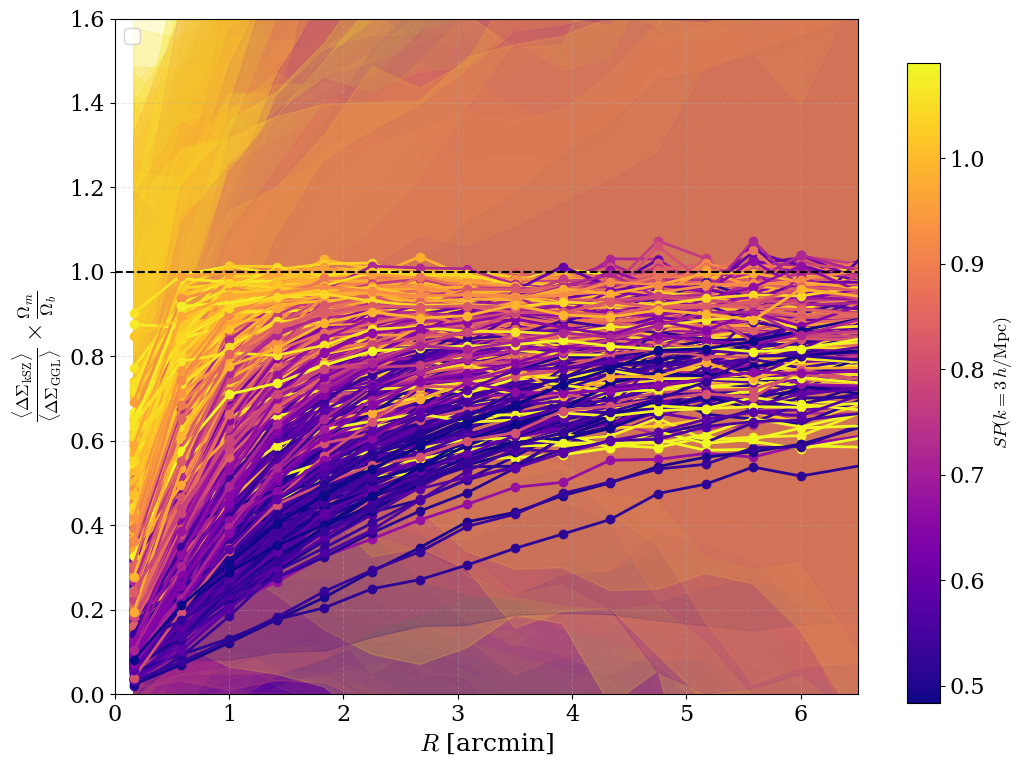

Plotting Number density 1: 1024 simulations × 3 projections × 35 halos
Saved profiles for number density 1 to /pscratch/sd/l/lindajin/DH_profile_kSZ_WL/data/_fifth_gen_makeMapDeltaSigma_kSZ_over_DeltaSigma_total_profiles_nd_1_n_35.npz
Saving figure to /pscratch/sd/l/lindajin/SimulationStacker/figures/2026-04/04-24/CAMELS_L50n512_SB35_n35_ionized_gas-DSigma_total-DSigma_compare_data_ratio_fifth_gen_makeMap_SPk10_nd1_z0.47.pdf


/tmp/ipykernel_403134/3027543336.py:93: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper left')
/tmp/ipykernel_403134/3027543336.py:95: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 0.82, 1])  # keep right margin reserved for colorbar


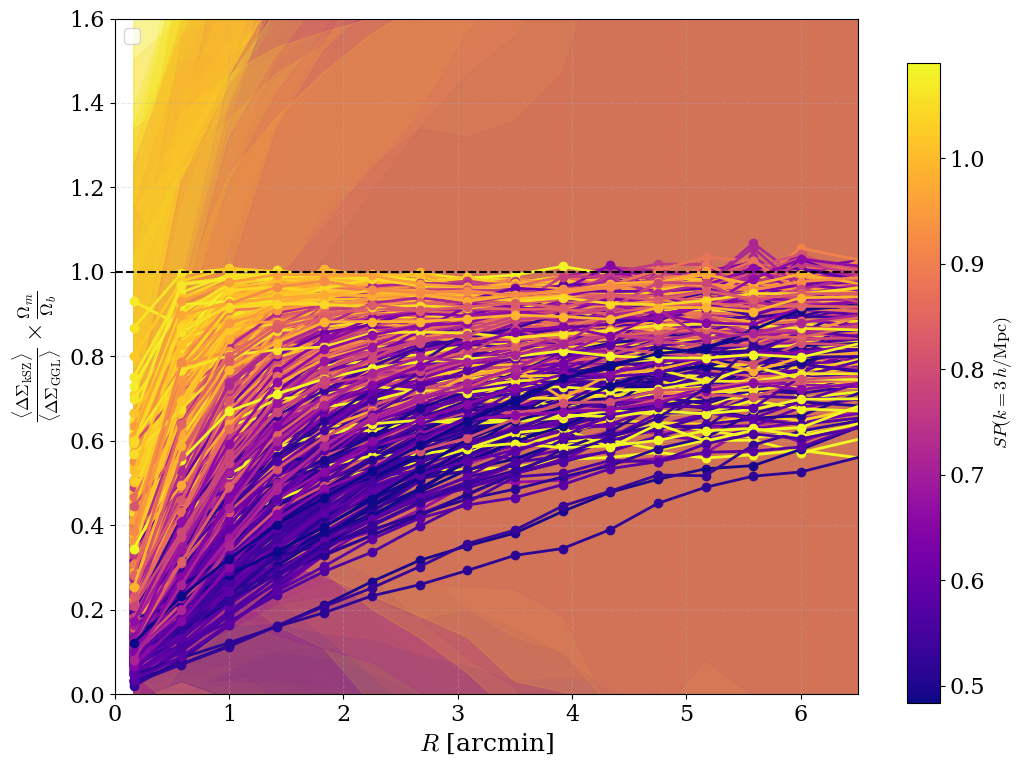

Plotting Number density 2: 1024 simulations × 3 projections × 62 halos
Saved profiles for number density 2 to /pscratch/sd/l/lindajin/DH_profile_kSZ_WL/data/_fifth_gen_makeMapDeltaSigma_kSZ_over_DeltaSigma_total_profiles_nd_2_n_62.npz
Saving figure to /pscratch/sd/l/lindajin/SimulationStacker/figures/2026-04/04-24/CAMELS_L50n512_SB35_n62_ionized_gas-DSigma_total-DSigma_compare_data_ratio_fifth_gen_makeMap_SPk10_nd2_z0.47.pdf


/tmp/ipykernel_403134/3027543336.py:93: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper left')
/tmp/ipykernel_403134/3027543336.py:95: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 0.82, 1])  # keep right margin reserved for colorbar


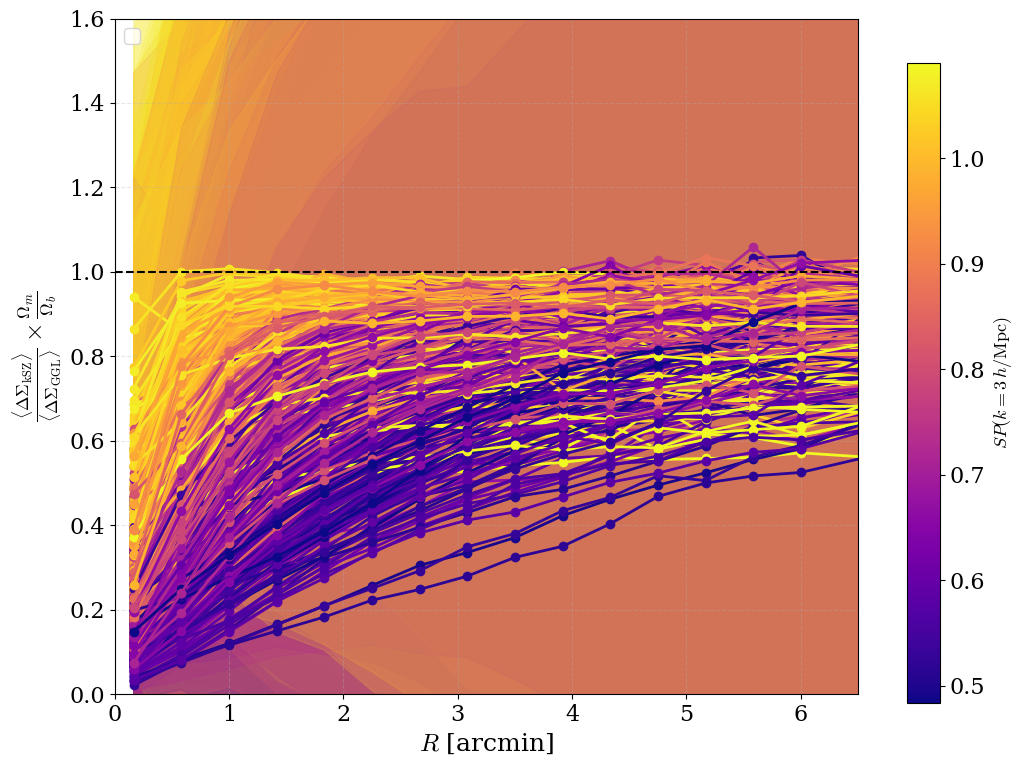

Plotting Number density 3: 1024 simulations × 3 projections × 125 halos
Saved profiles for number density 3 to /pscratch/sd/l/lindajin/DH_profile_kSZ_WL/data/_fifth_gen_makeMapDeltaSigma_kSZ_over_DeltaSigma_total_profiles_nd_3_n_125.npz
Saving figure to /pscratch/sd/l/lindajin/SimulationStacker/figures/2026-04/04-24/CAMELS_L50n512_SB35_n125_ionized_gas-DSigma_total-DSigma_compare_data_ratio_fifth_gen_makeMap_SPk10_nd3_z0.47.pdf


/tmp/ipykernel_403134/3027543336.py:93: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper left')
/tmp/ipykernel_403134/3027543336.py:95: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 0.82, 1])  # keep right margin reserved for colorbar


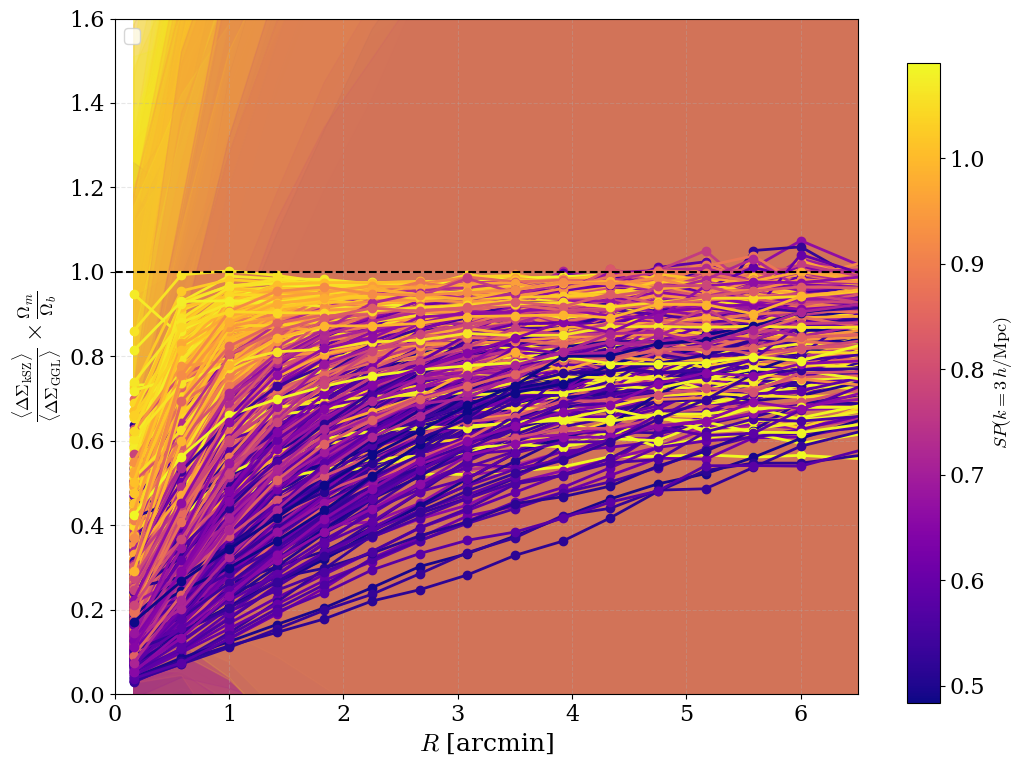

Plotting Number density 4: 1024 simulations × 3 projections × 300 halos
Saved profiles for number density 4 to /pscratch/sd/l/lindajin/DH_profile_kSZ_WL/data/_fifth_gen_makeMapDeltaSigma_kSZ_over_DeltaSigma_total_profiles_nd_4_n_300.npz
Saving figure to /pscratch/sd/l/lindajin/SimulationStacker/figures/2026-04/04-24/CAMELS_L50n512_SB35_n300_ionized_gas-DSigma_total-DSigma_compare_data_ratio_fifth_gen_makeMap_SPk10_nd4_z0.47.pdf


/tmp/ipykernel_403134/3027543336.py:93: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper left')
/tmp/ipykernel_403134/3027543336.py:95: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 0.82, 1])  # keep right margin reserved for colorbar


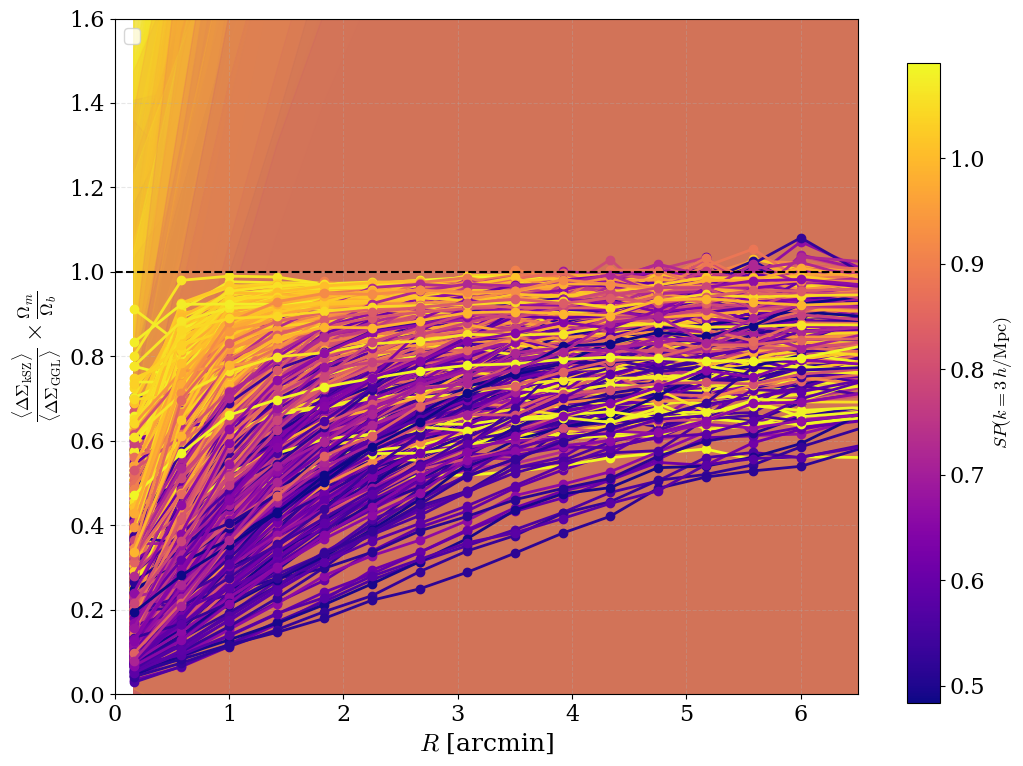

In [23]:
_f          = np.load(DATA_DIR + 'Ptot_Pdm_ratio_k_le15.npz')
_Ptot       = _f['Ptot_Pdm_ratio']   # shape (1024, n_k)
_k          = _f['k']
_k10_idx    = np.argmin(np.abs(_k - 3.0))
_cmap_sp    = matplotlib.colormaps['plasma']   
sp      = _Ptot[:, _k10_idx]       # SP(k=10) for every sim
sp_norm = plt.Normalize(vmin=sp.min(), vmax=sp.max())

# Rank-based coloring: evenly distributes the full colormap across all 1024 sims
sp_ranks   = np.argsort(np.argsort(sp))            # rank 0 = most suppressed
colors_all = _cmap_sp(sp_ranks / max(len(sp) - 1, 1))  # precomputed color per sim

for nd_idx, (n_halos, nd_label) in enumerate(zip(n_halos_per_density, nd_labels)):
    all_ratios_this_nd = [] 
    all_std_this_nd = []

    # Load profiles once, outside the loop
    profiles0 = np.load(DATA_DIR + f'mean_DeltaSigma_ionized_profiles_arcmin_nd_{nd_idx}_n_{n_halos}.npz')
    profiles1 = np.load(DATA_DIR + f'mean_DeltaSigma_total_profiles_arcmin_nd_{nd_idx}_n_{n_halos}.npz')

    print(f'Plotting Number density {nd_idx}: 1024 simulations × 3 projections × {n_halos} halos')
    fig, ax = plt.subplots(figsize=(11, 8))
    fig.subplots_adjust(right=0.82)   # leave room for colorbar on right

    for sim_i in range(1024):
        radii0 = profiles0['radii'][sim_i]  # in arcmin

        # ---- Ratio-of-means normalised by the cosmic baryon fraction ----
        f_baryon      = fb_all_sims[sim_i]  # Get this simulation's f_b
        mean0 = profiles0['prof'][sim_i,:]  # Shape: (n_radii,)
        mean1 = profiles1['prof'][sim_i,:]  # Shape: (n_radii,)
        profiles_plot = mean0 / mean1 / f_baryon

        err0 = profiles0['prof_std'][sim_i,:]
        err1 = profiles1['prof_std'][sim_i,:]
        profiles_err = np.abs(profiles_plot) * np.sqrt((err0 / mean0)**2 + (err1 / mean1)**2)

        all_ratios_this_nd.append(profiles_plot)
        all_std_this_nd.append(profiles_err)

        colour = colors_all[sim_i]

        ax.plot(
                    radii0 * rad_distance,
                    profiles_plot,
                    color=colour,
                    lw=2,
                    marker='o'
                )
                            
        ax.fill_between(
                        radii0 * rad_distance,
                        profiles_plot - profiles_err,
                        profiles_plot + profiles_err,
                        color=colour,
                        alpha=0.2,
                    )
    
    all_ratios_this_nd = np.array(all_ratios_this_nd)
    all_std_this_nd = np.array(all_std_this_nd)

    save_filename = DATA_DIR + NAME_EXTRA + f'DeltaSigma_kSZ_over_DeltaSigma_total_profiles_nd_{nd_idx}_n_{n_halos}.npz'
    np.savez(save_filename,
                prof=all_ratios_this_nd,
                prof_std=all_std_this_nd,
                radii=radii0,
                number_density=number_densities_to_plot[nd_idx],
                n_halos=n_halos,
                nd_label=nd_label)
    print(f"Saved profiles for number density {nd_idx} to {save_filename}")

    _sm = plt.cm.ScalarMappable(cmap=_cmap_sp, norm=sp_norm)
    _sm.set_array([])
    cbar_ax = fig.add_axes([0.84, 0.10, 0.03, 0.80])
    cbar    = fig.colorbar(_sm, cax=cbar_ax, orientation='vertical')
    cbar.set_label(
        r'$SP(k=3\,h/\mathrm{Mpc})$',
        fontsize=13,
    )
    pType = 'ionized_gas'
    filter_type = 'DSigma'
    label_pType = 'kSZ'
    pType2 ='total'
    filter_type2 = 'DSigma'
    label_pType2 = 'GGL'
    ax.axhline(1.0, color='k', ls='--', lw=1.5, label='_nolegend_')
    ax.set_xlabel(r'$R$ [arcmin]')
    ax.set_ylabel(
            rf'$\frac{{\langle \Delta \Sigma_{{\rm {label_pType}}} \rangle}}{{\langle \Delta \Sigma_{{\rm {label_pType2}}} \rangle}} \times \frac{{\Omega_m}}{{\Omega_b}}$'
    )
    ax.set_xlim(0.0, max_radius * rad_distance + 0.5)
    ax.set_ylim(0.0, 1.6)
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.3)
    fig.tight_layout(rect=[0, 0, 0.82, 1])  # keep right margin reserved for colorbar
    # ---- Save figure ----
    out_stem = f'CAMELS_{sim_name}_n{n_halos}_{pType}-{filter_type}_{pType2}-{filter_type2}_{fig_name}_SPk10_nd{nd_idx}_z{redshift}'
    out_path = FIG_SAVE_DIR / f'{out_stem}.pdf'
    print(f'Saving figure to {out_path}')
    fig.savefig(out_path, dpi=150)  # type: ignore
    plt.show()


Loaded _fifth_gen_makeMapDeltaSigma_kSZ_over_DeltaSigma_total_profiles_nd_0_n_12.npz: nd_idx=0, n_halos=12, n_sims=1024
Loaded _fifth_gen_makeMapDeltaSigma_kSZ_over_DeltaSigma_total_profiles_nd_1_n_35.npz: nd_idx=1, n_halos=35, n_sims=1024
Loaded _fifth_gen_makeMapDeltaSigma_kSZ_over_DeltaSigma_total_profiles_nd_2_n_62.npz: nd_idx=2, n_halos=62, n_sims=1024
Loaded _fifth_gen_makeMapDeltaSigma_kSZ_over_DeltaSigma_total_profiles_nd_3_n_125.npz: nd_idx=3, n_halos=125, n_sims=1024
Loaded _fifth_gen_makeMapDeltaSigma_kSZ_over_DeltaSigma_total_profiles_nd_4_n_300.npz: nd_idx=4, n_halos=300, n_sims=1024
Saved summary figure: /pscratch/sd/l/lindajin/SimulationStacker/figures/2026-04/04-24/DeltaSigma_kSZ_over_DeltaSigma_total_by_number_density_from_saved_files_fifth_gen_makeMap.pdf
Number densities plotted: 5


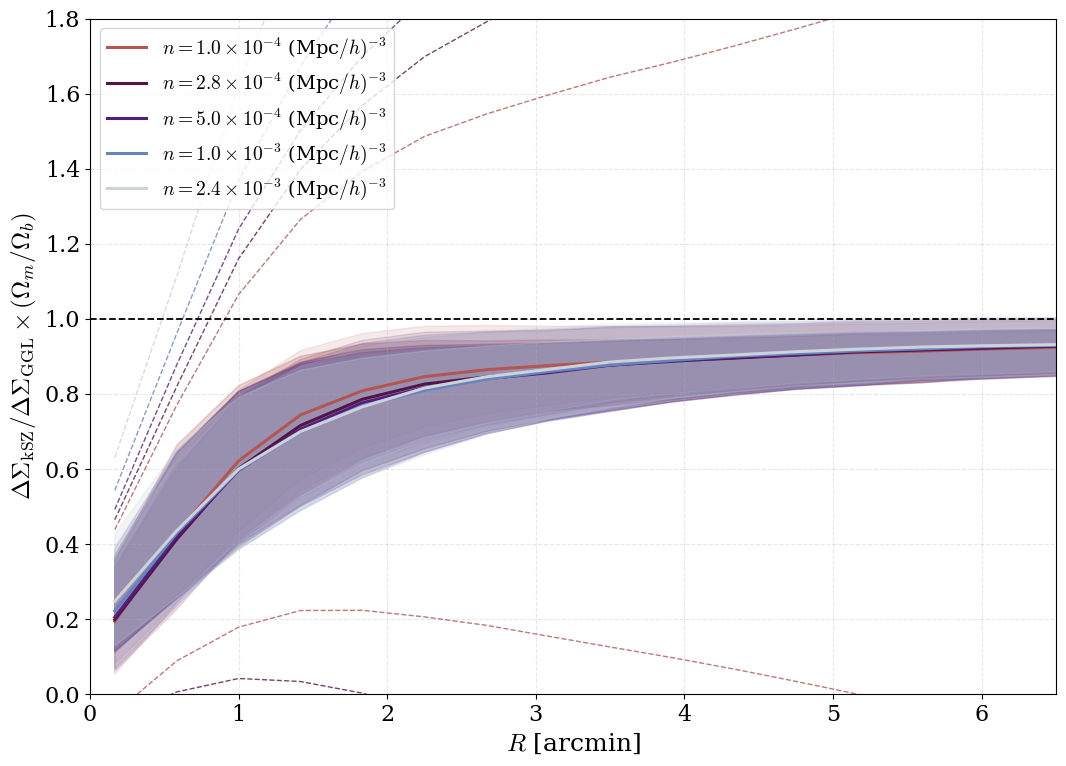

In [22]:
# Plot ionized/total ratio from saved NPZ files: all number densities in one figure
from pathlib import Path

# Reuse plotting colors from the active matplotlib cycle
prop_cycle = plt.rcParams['axes.prop_cycle']
cycle_colors = prop_cycle.by_key()['color']
nd_colors = [cycle_colors[i % len(cycle_colors)] for i in range(len(n_halos_per_density))]

fig, ax = plt.subplots(1, 1, figsize=(FIG_WIDTH_SINGLE, 8))
loaded_count = 0

for nd_idx, (n_halos, nd_label) in enumerate(zip(n_halos_per_density, nd_labels)):
    fname_core = f'DeltaSigma_kSZ_over_DeltaSigma_total_profiles_nd_{nd_idx}_n_{n_halos}.npz'
    candidate_paths = [
        Path(DATA_DIR) / f'{NAME_EXTRA}{fname_core}',
        Path(DATA_DIR) / fname_core,
    ]

    ratio_path = None
    for p in candidate_paths:
        if p.exists():
            ratio_path = p
            break

    if ratio_path is None:
        print(f'[skip] Missing ratio file for nd_idx={nd_idx}, n_halos={n_halos}')
        continue

    ratio_data = np.load(ratio_path)
    ratio_prof = ratio_data['prof']           # shape: (n_sims, n_radii)
    ratio_std  = ratio_data['prof_std']       # propagated per-sim uncertainty, same shape
    radii      = ratio_data['radii'] * rad_distance

    median_profile = np.nanmedian(ratio_prof, axis=0)
    p16_profile    = np.nanpercentile(ratio_prof, 16, axis=0)
    p84_profile    = np.nanpercentile(ratio_prof, 84, axis=0)
    std_profile    = np.nanstd(ratio_prof, axis=0)

    # Optional uncertainty estimate from propagated per-simulation errors.
    mean_err_profile = np.sqrt(np.nanmean(ratio_std**2, axis=0))

    n_r = min(len(radii), len(median_profile))
    r_plot = radii[:n_r]
    med    = median_profile[:n_r]
    p16    = p16_profile[:n_r]
    p84    = p84_profile[:n_r]
    stdp   = std_profile[:n_r]
    merr   = mean_err_profile[:n_r]

    color = nd_colors[nd_idx]

    # Main summary: median + simulation-to-simulation spread (16th-84th percentile).
    ax.plot(
        r_plot, med, color=color, linewidth=2.2,
        label=nd_label
    )
    ax.fill_between(r_plot, p16, p84, color=color, alpha=0.25)

    # Also show median +/- 1sigma across simulations as a lighter band.
    ax.fill_between(r_plot, med - stdp, med + stdp, color=color, alpha=0.12)

    # Dashed envelope from mean propagated per-simulation uncertainty.
    ax.plot(r_plot, med + merr, color=color, linestyle='--', linewidth=1.0, alpha=0.8)
    ax.plot(r_plot, med - merr, color=color, linestyle='--', linewidth=1.0, alpha=0.8)

    loaded_count += 1
    print(f'Loaded {ratio_path.name}: nd_idx={nd_idx}, n_halos={n_halos}, n_sims={ratio_prof.shape[0]}')

ax.axhline(1.0, color='k', linestyle='--', linewidth=1.3, label='_nolegend_')
ax.set_xlabel(r'$R$ [arcmin]')
ax.set_ylabel(r'$\Delta\Sigma_{\rm kSZ}/\Delta\Sigma_{\rm GGL}\times(\Omega_m/\Omega_b)$')
ax.set_xlim(0.0, max_radius * rad_distance + 0.5)
ax.set_ylim(0.0, 1.8)
ax.grid(True, which='both', alpha=0.3)
ax.legend(loc='upper left')

fig.tight_layout()
out_name = 'DeltaSigma_kSZ_over_DeltaSigma_total_by_number_density_from_saved_files' + NAME_EXTRA + '.pdf'
fig.savefig(FIG_SAVE_DIR / out_name, bbox_inches='tight', dpi=FIG_SAVE_DPI)
print(f'Saved summary figure: {FIG_SAVE_DIR / out_name}')
print(f'Number densities plotted: {loaded_count}')
plt.show()

# P(k)

In [13]:
f = np.load(DATA_DIR + 'Ptot_Pdm_ratio_k_le15.npz')
k=f['k']
Ptot_Pdm_ratio=f['Ptot_Pdm_ratio']


k=15 closest to k=14.891 (index 117)
k=10 closest to k=2.950 h/Mpc, SP range: [0.4836, 1.0904]


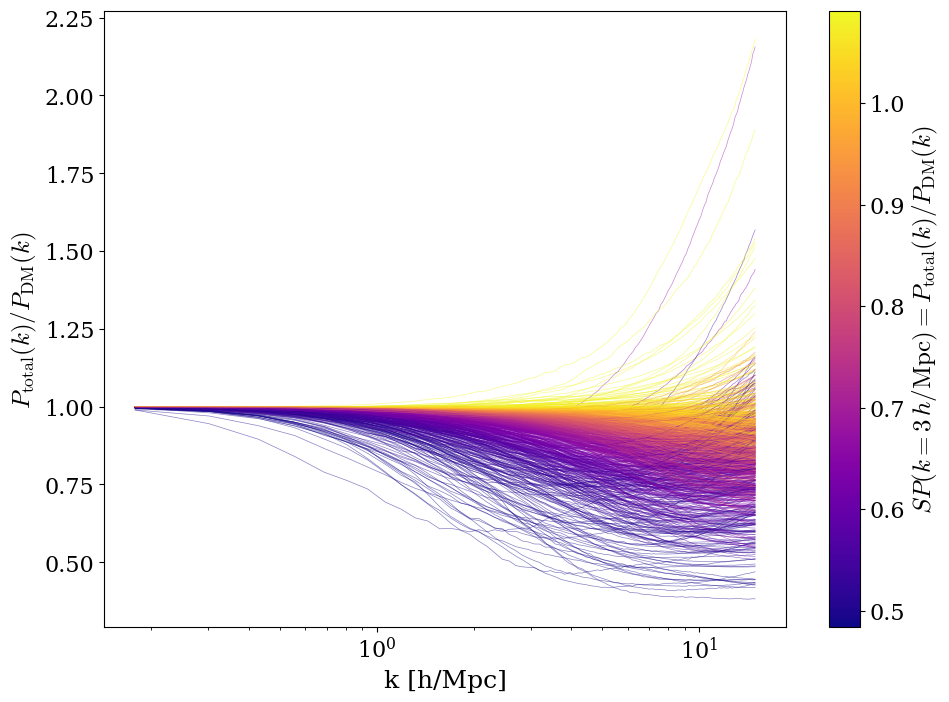

Saving figure to /pscratch/sd/l/lindajin/SimulationStacker/figures/2026-04/04-24/SP_k3_plasma_fifth_gen_makeMap.pdf


In [17]:
# Plot Ptot_Pdm_ratio colored by rank in SP(k=10) — same colormap as 4-panel figure below
k_max_idx = np.argmin(np.abs(k - 15.0))
print(f"k=15 closest to k={k[k_max_idx]:.3f} (index {k_max_idx})")

# SP(k) evaluated at k = 10 h/Mpc for each simulation
k10_idx   = np.argmin(np.abs(k - 3.0))
sp_at_k10 = Ptot_Pdm_ratio[:, k10_idx]
print(f"k=10 closest to k={k[k10_idx]:.3f} h/Mpc, SP range: [{sp_at_k10.min():.4f}, {sp_at_k10.max():.4f}]")

cmap_sp = plt.cm.plasma

# Rank-based coloring: evenly distributes the full colormap across all 1024 sims
sp_ranks   = np.argsort(np.argsort(sp_at_k10))       # rank 0 = most suppressed = darkest
colors_all = cmap_sp(sp_ranks / (len(sp_at_k10) - 1))

# Linear norm over actual SP values — used only for colorbar ticks
norm_cbar = plt.Normalize(vmin=sp_at_k10.min(), vmax=sp_at_k10.max())

fig, ax = plt.subplots(figsize=(FIG_WIDTH_SINGLE, 8))

for sim_id in range(len(Ptot_Pdm_ratio)):
    ax.plot(k[:k_max_idx+1], Ptot_Pdm_ratio[sim_id, :k_max_idx+1],
            color=colors_all[sim_id], alpha=0.5, linewidth=0.5)

sm = plt.cm.ScalarMappable(cmap=cmap_sp, norm=norm_cbar)
sm.set_array([])

ax.set_xlabel('k [h/Mpc]')
ax.set_xscale('log')
ax.set_ylabel(r'$P_{\rm total}(k) / P_{\rm DM}(k)$')

cbar = plt.colorbar(sm, ax=ax)
cbar.set_label(r'$SP(k=3\,h/\mathrm{Mpc}) = P_{\rm total}(k)/P_{\rm DM}(k)$')
plt.show()
out_stem = f'SP_k3_plasma'+NAME_EXTRA+'.pdf'
out_path = FIG_SAVE_DIR / out_stem
print(f'Saving figure to {out_path}')
fig.savefig(out_path, dpi=150)  # type: ignore
fig.tight_layout()
plt.show()

## Correlation Plot

k=10 closest to k=9.989 h/Mpc, SP range: [0.3860, 1.7083]


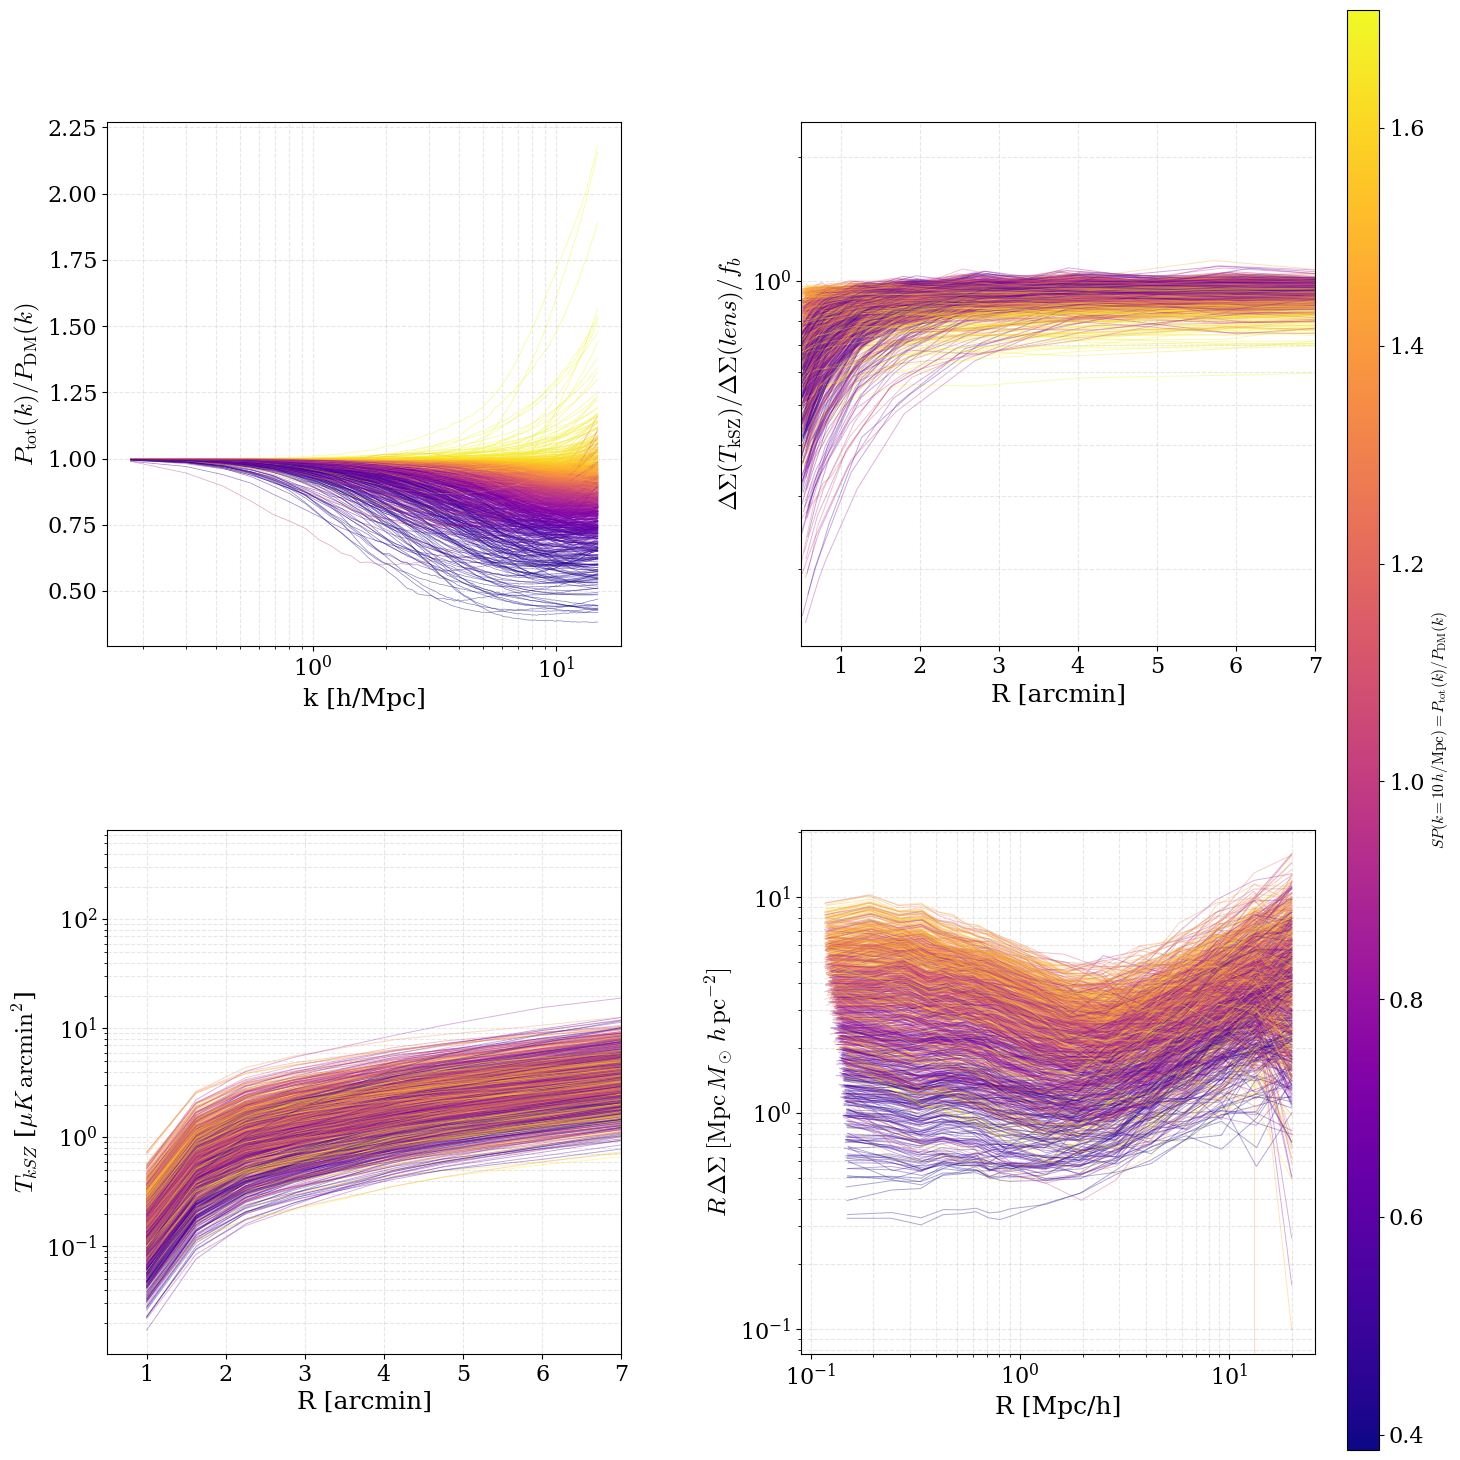

Saving figure to /pscratch/sd/l/lindajin/SimulationStacker/figures/2026-04/04-23/profiles_colored_by_SP_k10_plasma_N300_fifth_gen_makeMap.pdf


In [17]:
# Four-panel figure: SP(k), T_kSZ/ΔΣ(T_kSZ), T_kSZ, R·ΔΣ — all simulations
# Each simulation line colored by rank in SP(k=10), so the full colormap range
# is used evenly regardless of how the SP values cluster.

nd_idx_plot = -1
n_halos_plot = n_halos_per_density[nd_idx_plot]
z_lens = 0.47  # DESI LRG redshift
ratio_sims = []

k10_idx   = np.argmin(np.abs(k - 10.0))
k_max_idx = np.argmin(np.abs(k - 15.0))
sp_at_k10 = Ptot_Pdm_ratio[:, k10_idx]
print(f"k=10 closest to k={k[k10_idx]:.3f} h/Mpc, SP range: [{sp_at_k10.min():.4f}, {sp_at_k10.max():.4f}]")

cmap_sp = plt.cm.plasma

# Rank-based color: each sim gets a unique, evenly-spaced position in the colormap.
# argsort(argsort(x)) gives the rank of each element (0 = smallest SP = darkest).
sp_ranks   = np.argsort(np.argsort(sp_at_k10))           # shape (1024,), range [0, 1023]
colors_all = cmap_sp(sp_ranks / (len(sp_at_k10) - 1))    # RGBA array, shape (1024, 4)

# Linear norm over actual SP values — used only for the colorbar ticks
norm_cbar = plt.Normalize(vmin=sp_at_k10.min(), vmax=sp_at_k10.max())

fig, axes = plt.subplots(2, 2, figsize=(FIG_WIDTH_GRID, FIG_WIDTH_GRID))
fig.subplots_adjust(right=0.88, hspace=0.35, wspace=0.35)
ax_sp, ax_ratio, ax_ksz, ax_rds = axes.flatten()

for sim_id in range(len(ksz_profiles_xy_all_sims)):
    color = colors_all[sim_id]
    fb    = fb_all_sims[sim_id]

    # ── Panel 0: SP(k) ──────────────────────────────────────────────────
    ax_sp.plot(k[:k_max_idx+1], Ptot_Pdm_ratio[sim_id, :k_max_idx+1],
               color=color, alpha=0.5, linewidth=0.5)

    # ── kSZ: mean over halos × 3 projections, normalised by r_v ────────
    ksz_concat = np.concatenate([
        ksz_profiles_xy_all_sims[sim_id][:, :n_halos_plot],
        ksz_profiles_xz_all_sims[sim_id][:, :n_halos_plot],
        ksz_profiles_yz_all_sims[sim_id][:, :n_halos_plot],
    ], axis=1)
    ksz_mean = ksz_concat.mean(axis=1) / r_v_sims[sim_id]   # μK arcmin²

    # ── ΔΣ: mean over halos × 3 projections ────────────────────────────
    # Profiles stored in M_sun*h/kpc² (comoving).  ×1e-6 → M_sun*h/pc²
    ds_concat = np.concatenate([
        delta_sigma_xy_profiles_all_sims[sim_id][:, :n_halos_plot],
        delta_sigma_xz_profiles_all_sims[sim_id][:, :n_halos_plot],
        delta_sigma_yz_profiles_all_sims[sim_id][:, :n_halos_plot],
    ], axis=1)
    ds_mean_kpc2 = ds_concat.mean(axis=1)        # M_sun*h/kpc²  (comoving)
    ds_mean_pc2  = ds_mean_kpc2 * 1e-6           # M_sun*h/pc²   (comoving)

    ds_ionized_concat = np.concatenate([
        delta_sigma_ionized_xy_profiles_all_sims[sim_id][:, :n_halos_plot],
        delta_sigma_ionized_xz_profiles_all_sims[sim_id][:, :n_halos_plot],
        delta_sigma_ionized_yz_profiles_all_sims[sim_id][:, :n_halos_plot],
    ], axis=1)
    ds_ionized_mean_kpc2 = ds_ionized_concat.mean(axis=1)        # M_sun*h/kpc²  (comoving)
    ds_ionized_mean_pc2  = ds_ionized_mean_kpc2 * 1e-6           # M_sun*h/pc²   (comoving)

    # Radii
    radii_arcmin = r0_arcmin_all_sims[sim_id]    # arcmin  (kSZ filter radii)
    radii_mpch   = r1_mpch_all_sims[sim_id]      # Mpc/h   (ΔΣ filter radii)
    n_r          = min(len(radii_mpch), len(ds_mean_pc2))
    r_mask_ksz   = radii_arcmin[:len(ksz_mean)] >= 0.5

    # ── Panel 2: T_kSZ ──────────────────────────────────────────────────
    ax_ksz.plot(radii_arcmin[:len(ksz_mean)][r_mask_ksz],
                ksz_mean[r_mask_ksz],
                color=color, alpha=0.35, linewidth=0.7)

    # ── Panel 3: R·ΔΣ ───────────────────────────────────────────────────
    ax_rds.plot(radii_mpch[:n_r],
                ds_mean_pc2[:n_r] * radii_mpch[:n_r],
                color=color, alpha=0.35, linewidth=0.7)

    # ── Panel 1: T_kSZ / T_expected(ΔΣ) ────────────────────────────────
    ratio_sim     = ds_ionized_mean_pc2 / ds_mean_pc2  / fb # Dimensionless ratio of ionized gas fraction to cosmic baryon fraction
    ratio_sims.append(ratio_sim)
    n_r_ratio     = min(len(radii_mpch), len(ratio_sim))
    r_mask_ratio  = radii_mpch[:n_r_ratio] >= 0.5
    ax_ratio.plot(radii_mpch[:n_r_ratio][r_mask_ratio],
                  ratio_sim[r_mask_ratio],
                  color=color, alpha=0.35, linewidth=0.7)

# ── Shared colorbar spanning full figure height ──────────────────────────
sm = plt.cm.ScalarMappable(cmap=cmap_sp, norm=norm_cbar)
sm.set_array([])
cbar_ax = fig.add_axes([0.90, 0.05, 0.02, 0.90])
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='vertical')
cbar.set_label(r'$SP(k=10\,h/\mathrm{Mpc}) = P_{\rm tot}(k)/P_{\rm DM}(k)$',
               fontsize=11)

# ── Axes formatting ──────────────────────────────────────────────────────
ax_sp.set_xlabel('k [h/Mpc]')
ax_sp.set_xscale('log')
ax_sp.set_ylabel(r'$P_{\rm tot}(k) / P_{\rm DM}(k)$')
ax_sp.grid(True, which='both', alpha=0.3)

ax_ratio.set_xlabel('R [arcmin]')
ax_ratio.set_ylabel(r'$\Delta\Sigma(T_{\rm kSZ}) / \Delta\Sigma(lens) / f_b$')
ax_ratio.set_yscale('log')
ax_ratio.set_xlim(0.5, 7)
ax_ratio.grid(True, which='both', alpha=0.3)

ax_ksz.set_xlabel('R [arcmin]')
ax_ksz.set_ylabel(r'$T_{kSZ}$ [$\mu K\,\mathrm{arcmin}^2$]')
ax_ksz.set_yscale('log')
ax_ksz.set_xlim(0.5, 7)
ax_ksz.grid(True, which='both', alpha=0.3)

ax_rds.set_xlabel('R [Mpc/h]')
ax_rds.set_ylabel(r'$R\,\Delta\Sigma\;[\mathrm{Mpc}\,M_\odot\,h\,\mathrm{pc}^{-2}]$')
ax_rds.set_xscale('log')
ax_rds.set_yscale('log')
ax_rds.grid(True, which='both', alpha=0.3)

plt.show()
out_stem = f'profiles_colored_by_SP_k10_plasma_N{n_halos_plot}'+NAME_EXTRA+'.pdf'
out_path = FIG_SAVE_DIR / out_stem
print(f'Saving figure to {out_path}')
fig.savefig(out_path, dpi=150)  # type: ignore

In [24]:
ratio_sims = np.array(ratio_sims)  # shape (n_sims, n_radii)
ratio_saved = np.load('/pscratch/sd/l/lindajin/DH_profile_kSZ_WL/data/DeltaSigma_kSZ_over_DeltaSigma_total_profiles_nd_4_n_300.npz') ['prof']
radii = np.load('/pscratch/sd/l/lindajin/DH_profile_kSZ_WL/data/DeltaSigma_kSZ_over_DeltaSigma_total_profiles_nd_4_n_300.npz') ['radii']
print(ratio_sims-ratio_saved)

[[ 4.44089210e-16  6.66133815e-16  7.77156117e-16 ... -1.11022302e-16
  -1.88737914e-15  2.10942375e-15]
 [ 1.66533454e-16  5.55111512e-16  0.00000000e+00 ... -2.22044605e-16
  -1.55431223e-15  1.11022302e-16]
 [-2.22044605e-16  2.22044605e-16  2.22044605e-16 ...  9.99200722e-16
  -3.88578059e-15  1.99840144e-15]
 ...
 [ 1.22124533e-15  8.88178420e-16  1.44328993e-15 ...  1.22124533e-15
   5.55111512e-16  2.44249065e-15]
 [-1.11022302e-16 -1.44328993e-15  1.33226763e-15 ... -2.22044605e-16
   2.22044605e-16 -1.55431223e-15]
 [ 9.43689571e-16  5.55111512e-16 -2.22044605e-15 ...  5.55111512e-16
  -1.88737914e-15  1.66533454e-15]]


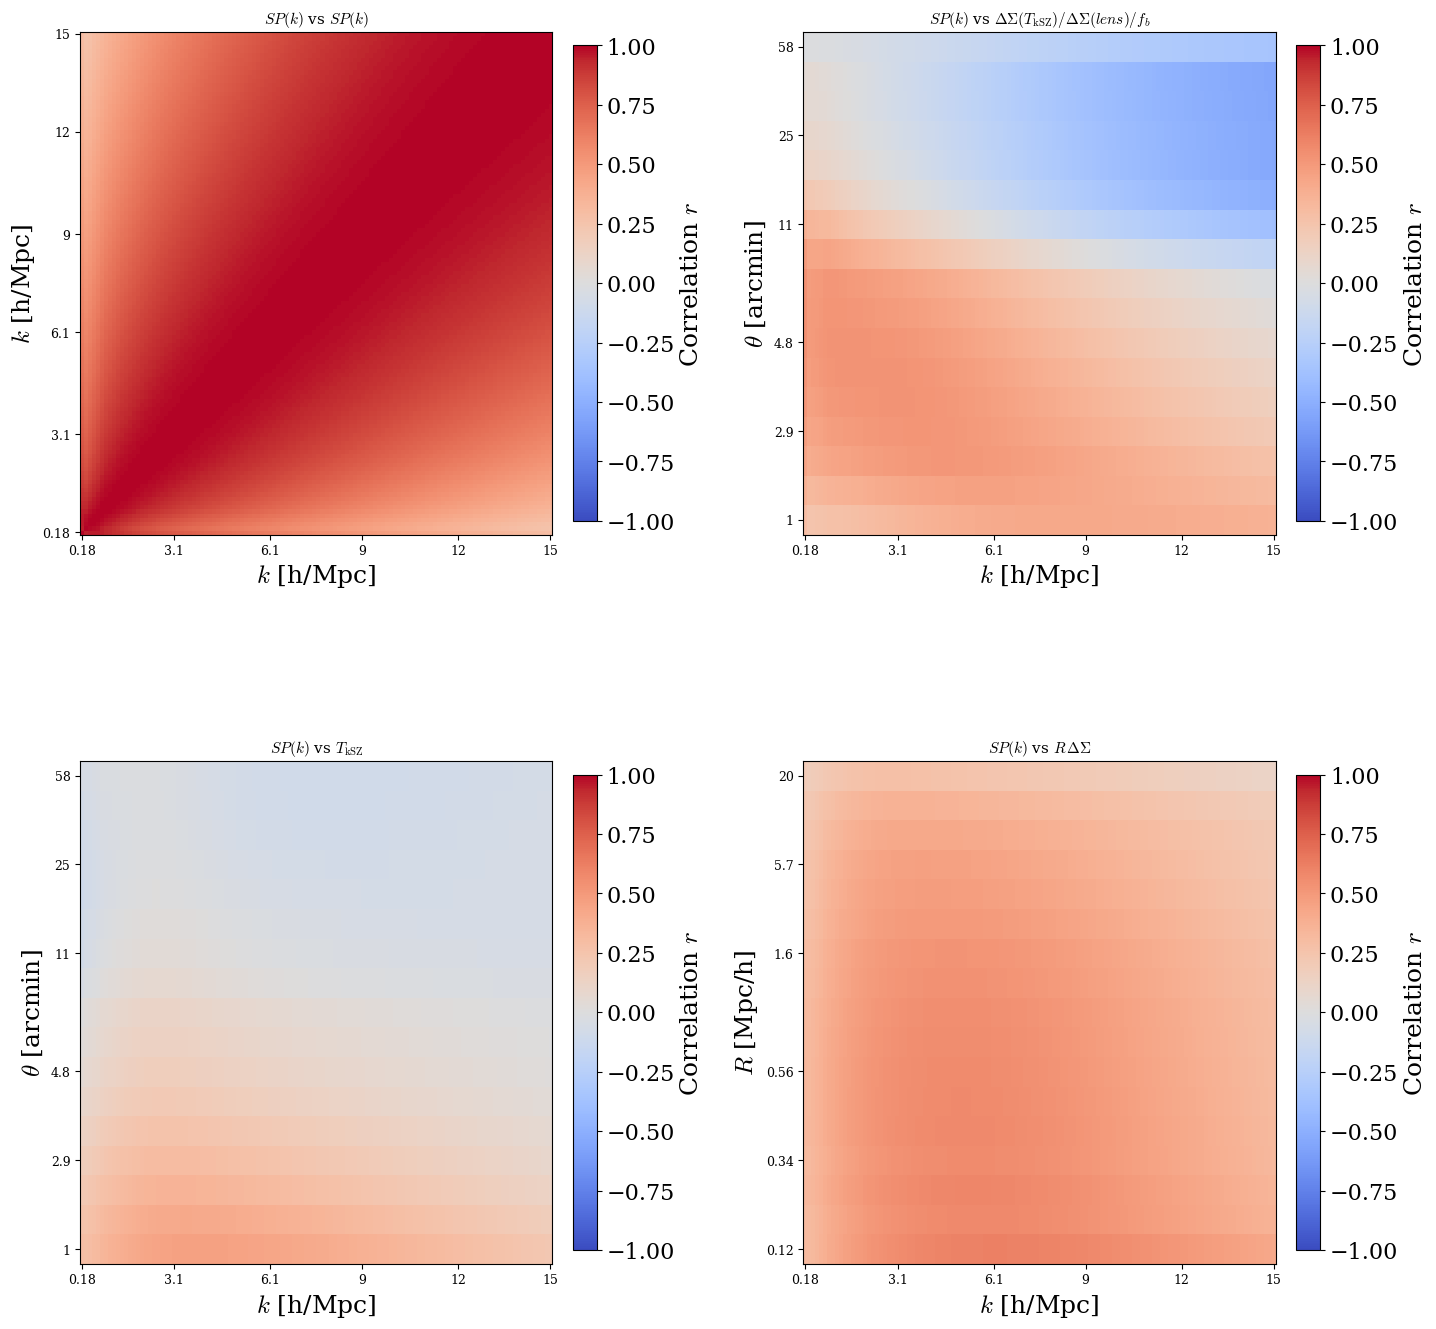

TypeError: unsupported operand type(s) for +: 'PosixPath' and 'str'

In [18]:
# Correlation matrices: SP(k) vs {SP(k), T_kSZ, R·ΔΣ, T_kSZ/T_expected(ΔΣ)}
# corr[i,j] = cov(X_i, Y_j) / sqrt(var(X_i) * var(Y_j))
#           = cross_cov / sqrt(outer(diag(cov_X), diag(cov_Y)))

n_halos_c = n_halos_per_density[nd_idx_plot]  # same nd as 4-panel cell above
n_sims    = len(ksz_profiles_xy_all_sims)
n_r_arc   = len(r0_arcmin_all_sims[0])
n_r_mpc   = len(r1_mpch_all_sims[0])

# Build per-simulation mean profile matrices: shape (n_sims, n_radii)
ksz_mat   = np.zeros((n_sims, n_r_arc))
rds_mat   = np.zeros((n_sims, n_r_mpc))   # R·ΔΣ
ratio_mat = np.zeros((n_sims, n_r_arc))   # T_kSZ / T_expected(ΔΣ)

for sim_id in range(n_sims):
    fb = fb_all_sims[sim_id]

    ksz_c = np.concatenate([
        ksz_profiles_xy_all_sims[sim_id][:, :n_halos_c],
        ksz_profiles_xz_all_sims[sim_id][:, :n_halos_c],
        ksz_profiles_yz_all_sims[sim_id][:, :n_halos_c],
    ], axis=1)
    ksz_mean = ksz_c.mean(axis=1) / r_v_sims[sim_id]   # μK arcmin²
    
    ds_c = np.concatenate([
        delta_sigma_xy_profiles_all_sims[sim_id][:, :n_halos_c],
        delta_sigma_xz_profiles_all_sims[sim_id][:, :n_halos_c],
        delta_sigma_yz_profiles_all_sims[sim_id][:, :n_halos_c],
    ], axis=1)
    ds_mean_kpc2 = ds_c.mean(axis=1)         # M_sun*h/kpc²  (comoving)
    ds_mean_pc2  = ds_mean_kpc2 * 1e-6       # M_sun*h/pc²
    
    ds_ionized_c = np.concatenate([
        delta_sigma_ionized_xy_profiles_all_sims[sim_id][:, :n_halos_c],
        delta_sigma_ionized_xz_profiles_all_sims[sim_id][:, :n_halos_c],
        delta_sigma_ionized_yz_profiles_all_sims[sim_id][:, :n_halos_c],
    ], axis=1)
    ds_ionized_mean_kpc2 = ds_ionized_c.mean(axis=1)   # M_sun*h/kpc²  (comoving)
    
    radii_mpch_s = r1_mpch_all_sims[sim_id]
    n_r          = min(len(radii_mpch_s), len(ds_mean_kpc2), n_r_mpc)
    
    ksz_mat[sim_id, :len(ksz_mean)]   = ksz_mean
    rds_mat[sim_id, :n_r]             = ds_mean_pc2[:n_r] * radii_mpch_s[:n_r]
    ratio_mat[sim_id, :n_r]           = (ds_ionized_mean_kpc2 / ds_mean_kpc2 / fb)[:n_r]

# SP(k) matrix: shape (n_sims, n_k)
sp_mat = Ptot_Pdm_ratio[:, :k_max_idx+1]   # (1024, n_k)
k_vals = k[:k_max_idx+1]

# Reference radii axes
radii_arc_ref = r0_arcmin_all_sims[0]        # arcmin
radii_mpc_ref = r1_mpch_all_sims[0]          # Mpc/h
r_mask_arc    = radii_arc_ref >= 0.5

# ── Correlation matrix: corr = cross_cov / sqrt(outer(var_X, var_Y)) ────
# For each pair (X, Y) with shapes (n_sims, p) and (n_sims, q):
#   cross_cov[i,j] = cov(X[:,i], Y[:,j])     shape (p, q)
#   corr[i,j]      = cross_cov[i,j] / sqrt(var(X[:,i]) * var(Y[:,j]))
#                  = cross_cov / sqrt(outer(diag(cov_X), diag(cov_Y)))
def corr_cross(X, Y):
    n = X.shape[0]
    Xc = X - X.mean(axis=0)
    Yc = Y - Y.mean(axis=0)
    cross_cov = Xc.T @ Yc / (n - 1)                      # (p, q)
    var_X = (Xc**2).sum(axis=0) / (n - 1)                # (p,)
    var_Y = (Yc**2).sum(axis=0) / (n - 1)                # (q,)
    denom = np.sqrt(np.outer(var_X, var_Y))               # (p, q)
    return cross_cov / np.where(denom == 0, np.nan, denom)

corr_sp_sp    = corr_cross(sp_mat, sp_mat)                       # (n_k, n_k)
corr_sp_ksz   = corr_cross(sp_mat, ksz_mat [:, r_mask_arc])      # (n_k, n_r_arc_masked)
corr_sp_rds   = corr_cross(sp_mat, rds_mat)                      # (n_k, n_r_mpc)
corr_sp_ratio = corr_cross(sp_mat, ratio_mat[:, r_mask_arc])     # (n_k, n_r_arc_masked)

arc_masked = radii_arc_ref[r_mask_arc]

# Helper: sparse tick indices
def sparse_ticks(vals, n_ticks=6):
    idx = np.round(np.linspace(0, len(vals)-1, n_ticks)).astype(int)
    return idx, vals[idx]

# ── 2×2 figure ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(FIG_WIDTH_GRID, FIG_WIDTH_GRID))
fig.subplots_adjust(hspace=0.45, wspace=0.4)

panels = [
    (axes[0,0], corr_sp_sp,        k_vals,        k_vals,
     r'$k$ [h/Mpc]',       r'$k$ [h/Mpc]',
     r'$SP(k)$ vs $SP(k)$'),
    (axes[1,0], corr_sp_ksz.T,    k_vals,        arc_masked,
     r'$k$ [h/Mpc]',       r'$\theta$ [arcmin]',
     r'$SP(k)$ vs $T_{\rm kSZ}$'),
    (axes[1,1], corr_sp_rds.T,    k_vals,        radii_mpc_ref,
     r'$k$ [h/Mpc]',       r'$R$ [Mpc/h]',
     r'$SP(k)$ vs $R\,\Delta\Sigma$'),
    (axes[0,1], corr_sp_ratio.T,  k_vals,        arc_masked,
     r'$k$ [h/Mpc]',       r'$\theta$ [arcmin]',
     r'$SP(k)$ vs $\Delta\Sigma(T_{\rm kSZ})/\Delta\Sigma(lens)/f_b$'),
]

for ax, corr, x_vals, y_vals, xlabel, ylabel, title in panels:
    im = ax.imshow(corr, origin='lower', aspect='auto',
                   cmap='coolwarm', vmin=-1, vmax=1,
                   rasterized=True)
    plt.colorbar(im, ax=ax, label='Correlation $r$', fraction=0.046, pad=0.04)

    xi, xv = sparse_ticks(x_vals)
    ax.set_xticks(xi)
    ax.set_xticklabels([f'{v:.2g}' for v in xv], fontsize=9)

    yi, yv = sparse_ticks(y_vals)
    ax.set_yticks(yi)
    ax.set_yticklabels([f'{v:.2g}' for v in yv], fontsize=9)

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontsize=11)

plt.show()
fig.savefig(FIG_SAVE_DIR + f'correlation_matrix_SP_vs_profiles_N{n_halos_c}'+NAME_EXTRA+'.pdf', bbox_inches='tight', dpi=FIG_SAVE_DPI)


## Scatter Plot

k=0.3 closest to k=0.302, k=1 closest to k=1.062
θ=3 arcmin closest to θ=3.083 arcmin (index 7)
Bigwoods Bin 0: 411 halos in all simulations
Bigwoods Bin 1: 1024 halos in all simulations
Bigwoods Bin 2: 1024 halos in all simulations


Bigwoods Bin 3: 1019 halos in all simulations
Bigwoods Bin 4: 921 halos in all simulations
Bigwoods Bin 5: 487 halos in all simulations


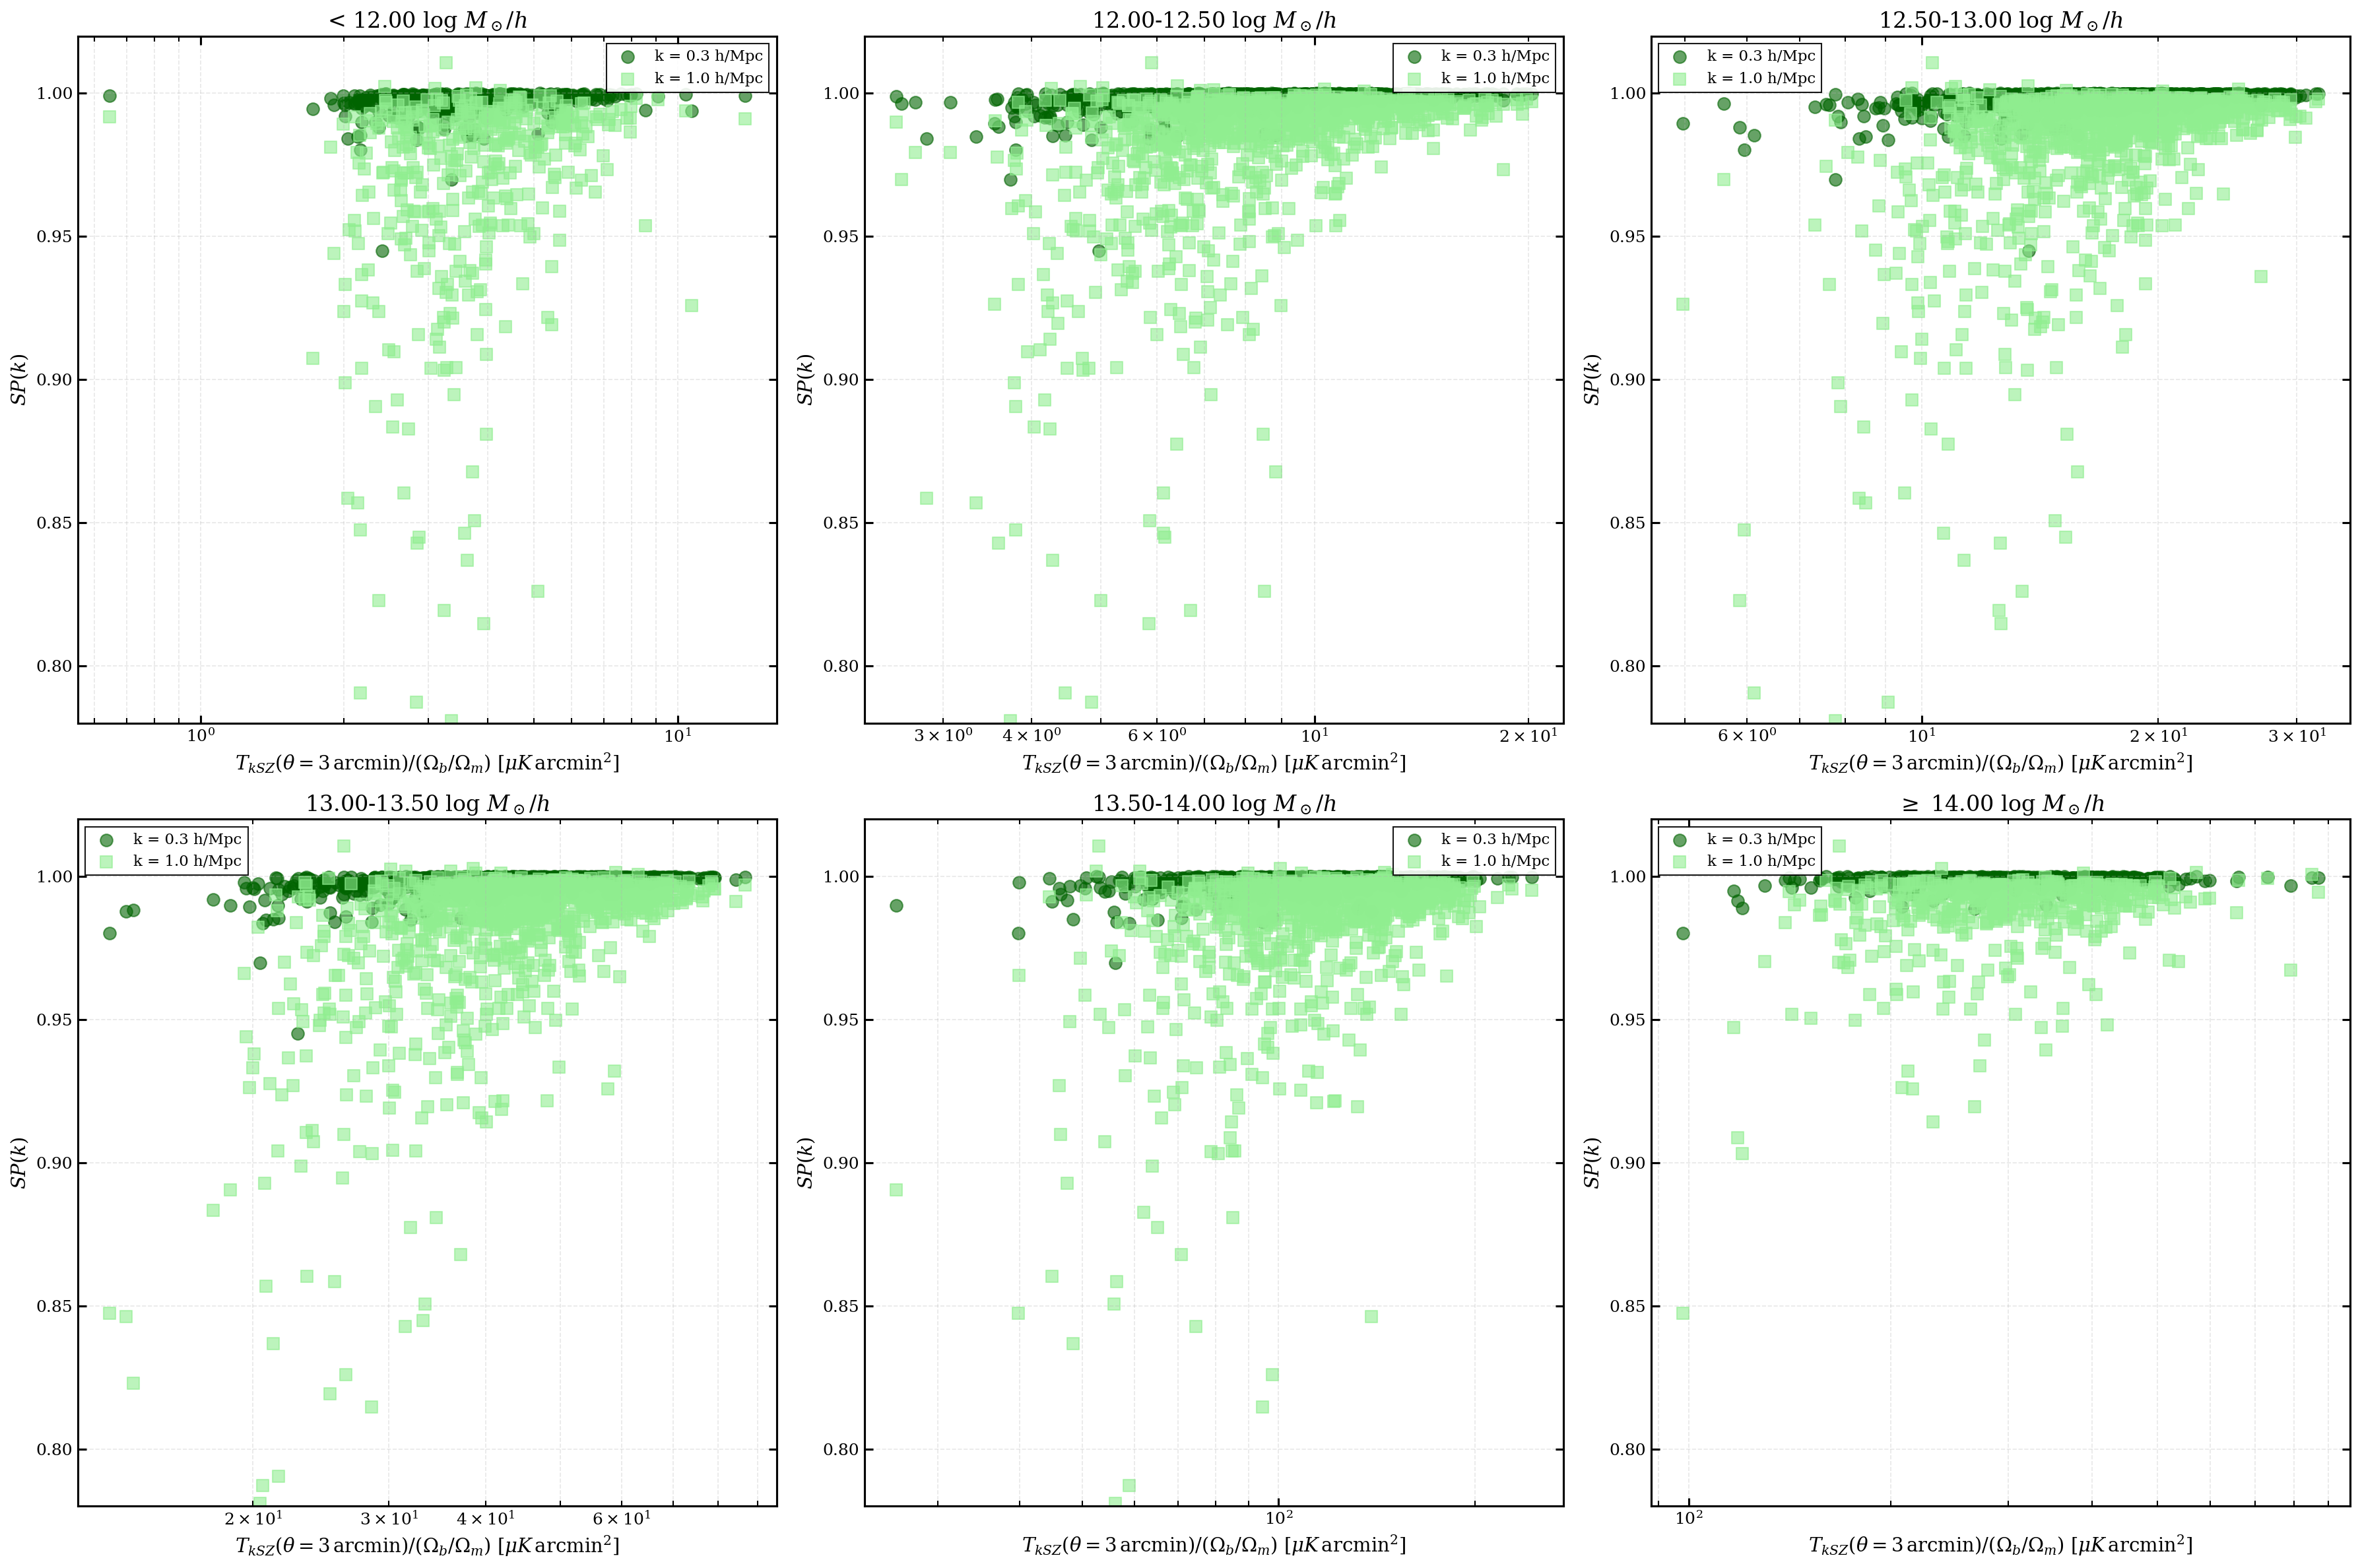

In [ ]:
# Recreate plot matching the image format: kSZ at θ=3 arcmin vs SP(k)

# Get radial bins
radii = r0_arcmin  # in arcmin

# Mass bin labels for Bigwoods binning - 6 bins total
bigwoods_mass_bin_labels = [
    r'< 12.00 log $M_\odot/h$',
    r'12.00-12.50 log $M_\odot/h$',
    r'12.50-13.00 log $M_\odot/h$',
    r'13.00-13.50 log $M_\odot/h$',
    r'13.50-14.00 log $M_\odot/h$',
    r'$\geq$ 14.00 log $M_\odot/h$'
]

# Get SP(k) values at k=0.3 and k=1

k_03_idx = np.argmin(np.abs(k - 0.3 ))
k_1_idx = np.argmin(np.abs(k - 1.0))

print(f"k=0.3 closest to k={k[k_03_idx]:.3f}, k=1 closest to k={k[k_1_idx]:.3f}")

# Find index closest to θ=3 arcmin
theta_3arcmin_idx = np.argmin(np.abs(radii - 3.0))
print(f"θ=3 arcmin closest to θ={radii[theta_3arcmin_idx]:.3f} arcmin (index {theta_3arcmin_idx})")

fig, axes = plt.subplots(2, 3, figsize=(FIG_WIDTH_SINGLE*3, FIG_WIDTH_GRID))
axes = axes.flatten()

# Process each mass bin (6 bins: 0, 1, 2, 3, 4, 5)
for mass_bin_idx in range(6):
    ax = axes[mass_bin_idx]
    
    # Collect kSZ at θ=3 arcmin and SP(k) values for each simulation
    ksz_at_3arcmin_list = []
    sp_k03_list = []
    sp_k1_list = []
    
    for sim_id in range(len(ksz_profiles_xy_all_sims)):
        sim_profiles_xy = ksz_profiles_xy_all_sims[sim_id]
        sim_profiles_xz = ksz_profiles_xz_all_sims[sim_id]
        sim_profiles_yz = ksz_profiles_yz_all_sims[sim_id]
        
        bin_indices = ksz_halo_bigwoods_mass_bin_idx_all_sims[sim_id]
        mask= (bin_indices == mass_bin_idx)
        fb = fb_all_sims[sim_id]
        
        if np.sum(mask) > 0:
            # Calculate median kSZ at θ=3 arcmin for this simulation's halos in this mass bin
            profiles_xy = sim_profiles_xy[:, mask]
            profiles_xz = sim_profiles_xz[:, mask]
            profiles_yz = sim_profiles_yz[:, mask]
            profiles_this_bin = np.concatenate([profiles_xy, profiles_xz, profiles_yz], axis=1) #sim_profiles[:, mask]
            median_ksz_at_3arcmin = np.nanmean(profiles_this_bin[theta_3arcmin_idx, :])
            ksz_at_3arcmin_list.append(median_ksz_at_3arcmin/fb)
            
            # Get SP(k) for this simulation
            sp_ratio = Ptot_Pdm_ratio[sim_id]
            sp_k03_list.append(sp_ratio[k_03_idx])
            sp_k1_list.append(sp_ratio[k_1_idx])

            
    # Scatter plot: kSZ at θ=3 arcmin (x-axis) vs SP(k) (y-axis)
    # Dark green for k=0.3
    ax.scatter(ksz_at_3arcmin_list, sp_k03_list, 
              color='darkgreen', marker='o', s=80, alpha=0.6, 
              label=f'k = 0.3 h/Mpc')
    
    # Light green for k=1
    ax.scatter(ksz_at_3arcmin_list, sp_k1_list, 
              color='lightgreen', marker='s', s=80, alpha=0.6, 
              label=f'k = 1.0 h/Mpc')
    
    print(f"Bigwoods Bin {mass_bin_idx}: {len(ksz_at_3arcmin_list)} halos in all simulations")
    
    # Set labels and formatting
    ax.set_xlabel(r'$T_{kSZ}(\theta=3\,\mathrm{arcmin})/(\Omega_b/\Omega_m)$ [$\mu K \, \mathrm{arcmin}^2$]')
    ax.set_ylabel(r'$SP(k)$')
    ax.set_xscale('log')
    
    ax.set_ylim(0.78, 1.02)
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3, which='both')
    ax.set_title(f'{bigwoods_mass_bin_labels[mass_bin_idx]}')

# fig.suptitle(r'Bigwood et al. 2025 Fig. 8', fontsize=18, y=0.995)
fig.tight_layout()
plt.show()
fig.savefig(FIG_SAVE_DIR + 'kSZ_3arcmin_vs_SP'+NAME_EXTRA+'.pdf', bbox_inches='tight', dpi=FIG_SAVE_DPI)


# Ratio vs. SP(k)

In [ ]:


def plot_ratio_vs_suppression(k_value1=1.0, k_value2=10.0, theta_arcmin_value1=6.0, theta_arcmin_value2=None):
    """
    Plot T_kSZ/Delta Sigma ratio vs power spectrum suppression SP(k).
    
    Parameters:
    -----------
    k_value1 : float
        First k-value in h/Mpc (default: 1.0)
    k_value2 : float
        Second k-value in h/Mpc (default: 10.0)
    theta_arcmin_value1 : float
        First angular scale in arcmin to evaluate profiles (default: 6.0)
    theta_arcmin_value2 : float, optional
        Second angular scale in arcmin. If provided, x-axis will be the difference
        (larger - smaller) between ratios at the two angular scales (default: None)
    """
    # Mass bin labels for Bigwoods binning - 6 bins total
    bigwoods_mass_bin_labels = [
        r'< 12.00 log $M_\odot/h$',
        r'12.00-12.50 log $M_\odot/h$',
        r'12.50-13.00 log $M_\odot/h$',
        r'13.00-13.50 log $M_\odot/h$',
        r'13.50-14.00 log $M_\odot/h$',
        r'$\geq$ 14.00 log $M_\odot/h$'
    ]

    # Get SP(k) values at specified k-values
    k1_idx = np.argmin(np.abs(k - k_value1))
    k2_idx = np.argmin(np.abs(k - k_value2))

    print(f"k={k_value1} closest to k={k[k1_idx]:.3f}, k={k_value2} closest to k={k[k2_idx]:.3f}")
    
    # Determine if we're plotting difference or single value
    if theta_arcmin_value2 is not None:
        # Ensure larger - smaller for positive difference
        theta_large = max(theta_arcmin_value1, theta_arcmin_value2)
        theta_small = min(theta_arcmin_value1, theta_arcmin_value2)
        print(f"Using θ difference: {theta_large:.1f} - {theta_small:.1f} arcmin")
        use_difference = True
    else:
        print(f"Using θ={theta_arcmin_value1} arcmin")
        use_difference = False

    fig, axes = plt.subplots(2, 3, figsize=(FIG_WIDTH_DOUBLE, 12))
    axes = axes.flatten()

    # Process each mass bin (6 bins: 0, 1, 2, 3, 4, 5)
    for mass_bin_idx in range(6):
        ax = axes[mass_bin_idx]
        
        # Collect T_kSZ/Delta Sigma ratio at specified theta and SP(k) values for each simulation
        ksz_dsigma_ratio_list = []
        sp_k1_list = []
        sp_k2_list = []
        
        for sim_id in range(len(ksz_profiles_xy_all_sims)):
            bin_indices = ksz_halo_bigwoods_mass_bin_idx_all_sims[sim_id]
            mask = np.zeros_like(bin_indices)
            mask = (bin_indices == mass_bin_idx)
            fb = fb_all_sims[sim_id]
            
            if np.sum(mask) > 0:
                # Calculate median kSZ at θ=3 arcmin for this simulation's halos in this mass bin
                profiles_xy =  ksz_profiles_xy_all_sims[sim_id][:, mask]
                profiles_xz =  ksz_profiles_xz_all_sims[sim_id][:, mask]
                profiles_yz =  ksz_profiles_yz_all_sims[sim_id][:, mask]
                
                # Concatenate kSZ profiles from all projections
                ksz_profiles_this_bin = np.concatenate([profiles_xy, profiles_xz, profiles_yz], axis=1)
                
                # For Delta Sigma, check if arcmin versions exist for all projections
                # If not, use only xy projection
                if (delta_sigma_arcmin_xz_profiles_all_sims[sim_id] is not None and 
                    delta_sigma_arcmin_yz_profiles_all_sims[sim_id] is not None):
                    # All projections available in arcmin
                    dsigma_profiles_xy = delta_sigma_arcmin_xy_profiles_all_sims[sim_id][:, mask]
                    dsigma_profiles_xz = delta_sigma_arcmin_xz_profiles_all_sims[sim_id][:, mask]
                    dsigma_profiles_yz = delta_sigma_arcmin_yz_profiles_all_sims[sim_id][:, mask]
                    dsigma_profiles_this_bin = np.concatenate([dsigma_profiles_xy, dsigma_profiles_xz, dsigma_profiles_yz], axis=1)
                else:
                    # Only xy projection available, replicate it for each kSZ halo
                    # Since we have 3x kSZ halos but only 1x dsigma, tile the dsigma profiles
                    dsigma_profiles_xy = delta_sigma_arcmin_xy_profiles_all_sims[sim_id][:, mask]
                    dsigma_profiles_this_bin = np.tile(dsigma_profiles_xy, 3)
                
                if use_difference:
                    # Calculate ratio at both angular scales
                    # For larger theta
                    theta_idx_ksz_large = np.argmin(np.abs(r0_arcmin_all_sims[sim_id] - theta_large))
                    theta_idx_dsigma_large = np.argmin(np.abs(r1_arcmin_all_sims[sim_id] - theta_large))
                    ratio_large = (ksz_profiles_this_bin[theta_idx_ksz_large, :] / fb) / dsigma_profiles_this_bin[theta_idx_dsigma_large, :]
                    
                    # For smaller theta
                    theta_idx_ksz_small = np.argmin(np.abs(r0_arcmin_all_sims[sim_id] - theta_small))
                    theta_idx_dsigma_small = np.argmin(np.abs(r1_arcmin_all_sims[sim_id] - theta_small))
                    ratio_small = (ksz_profiles_this_bin[theta_idx_ksz_small, :] / fb) / dsigma_profiles_this_bin[theta_idx_dsigma_small, :]
                    
                    # Calculate difference (larger - smaller)
                    ratio =  np.nanmedian(ratio_large - ratio_small)
                else:
                    # Single theta value
                    theta_idx_ksz = np.argmin(np.abs(r0_arcmin_all_sims[sim_id] - theta_arcmin_value1))
                    theta_idx_dsigma = np.argmin(np.abs(r1_arcmin_all_sims[sim_id] - theta_arcmin_value1))
                    ratio = np.nanmedian((ksz_profiles_this_bin[theta_idx_ksz, :] / fb) / 
                                        dsigma_profiles_this_bin[theta_idx_dsigma, :])
                
                ksz_dsigma_ratio_list.append(ratio)
                
                # Get SP(k) for this simulation
                sp_ratio = Ptot_Pdm_ratio[sim_id]
                sp_k1_list.append(sp_ratio[k1_idx])
                sp_k2_list.append(sp_ratio[k2_idx])
        
        if len(ksz_dsigma_ratio_list) > 0:
            
            # Scatter plot: T_kSZ/Delta Sigma ratio (x-axis) vs SP(k) (y-axis)
            ax.scatter(ksz_dsigma_ratio_list, sp_k1_list, 
                      color='darkgreen', marker='o', s=80, alpha=0.6, 
                      label=f'k = {k_value1} h/Mpc')
            
            ax.scatter(ksz_dsigma_ratio_list, sp_k2_list, 
                      color='lightgreen', marker='s', s=80, alpha=0.6, 
                      label=f'k = {k_value2} h/Mpc')
            
            # Set labels and formatting
            if use_difference:
                xlabel = (r'$\Delta[T_{kSZ}/\Delta\Sigma]/(\Omega_b/\Omega_m)$ ' + 
                         f'($\\theta={theta_large:.1f}-{theta_small:.1f}$ arcmin) ' +
                         r'[$\mu K \mathrm{arcmin}^4 / M_\odot h$]')
                title_text = f'{theta_large:.1f} - {theta_small:.1f} arcmin'
            else:
                xlabel = r'$[T_{kSZ}/\Delta\Sigma](\theta=' + f'{theta_arcmin_value1:.1f}' + r'\,\mathrm{arcmin})/(\Omega_b/\Omega_m)$ [$\mu K \mathrm{arcmin}^4 / M_\odot h$]'
                title_text = f'{theta_arcmin_value1:.1f} arcmin'
            
            ax.set_xlabel(xlabel)
            ax.set_ylabel(r'$SP(k)$')
            
            # Only use log scale if not using difference (difference can be negative)
            if not use_difference:
                ax.set_xscale('log')
            
            ax.set_ylim(0.78, 1.02)
            ax.legend(loc='best')
            ax.grid(True, which='both')
            ax.set_title(f'{bigwoods_mass_bin_labels[mass_bin_idx]}')

    fig.tight_layout()
    # Create filename based on parameters
    if use_difference:
        filename = f'ratio_vs_SP_theta_diff_{theta_large:.1f}_{theta_small:.1f}_k_{k_value1:.1f}_{k_value2:.1f}'+NAME_EXTRA+'.pdf'
    else:
        filename = f'ratio_vs_SP_theta_{theta_arcmin_value1:.1f}_k_{k_value1:.1f}_{k_value2:.1f}'+NAME_EXTRA+'.pdf'
    fig.savefig(FIG_SAVE_DIR + filename, bbox_inches='tight', dpi=FIG_SAVE_DPI)

    plt.show()# Call the function with default values (k=1.0, k=10.0, theta=6.0 arcmin)


k=0.3 closest to k=0.302, k=1.0 closest to k=1.062
Using θ difference: 3.0 - 1.0 arcmin


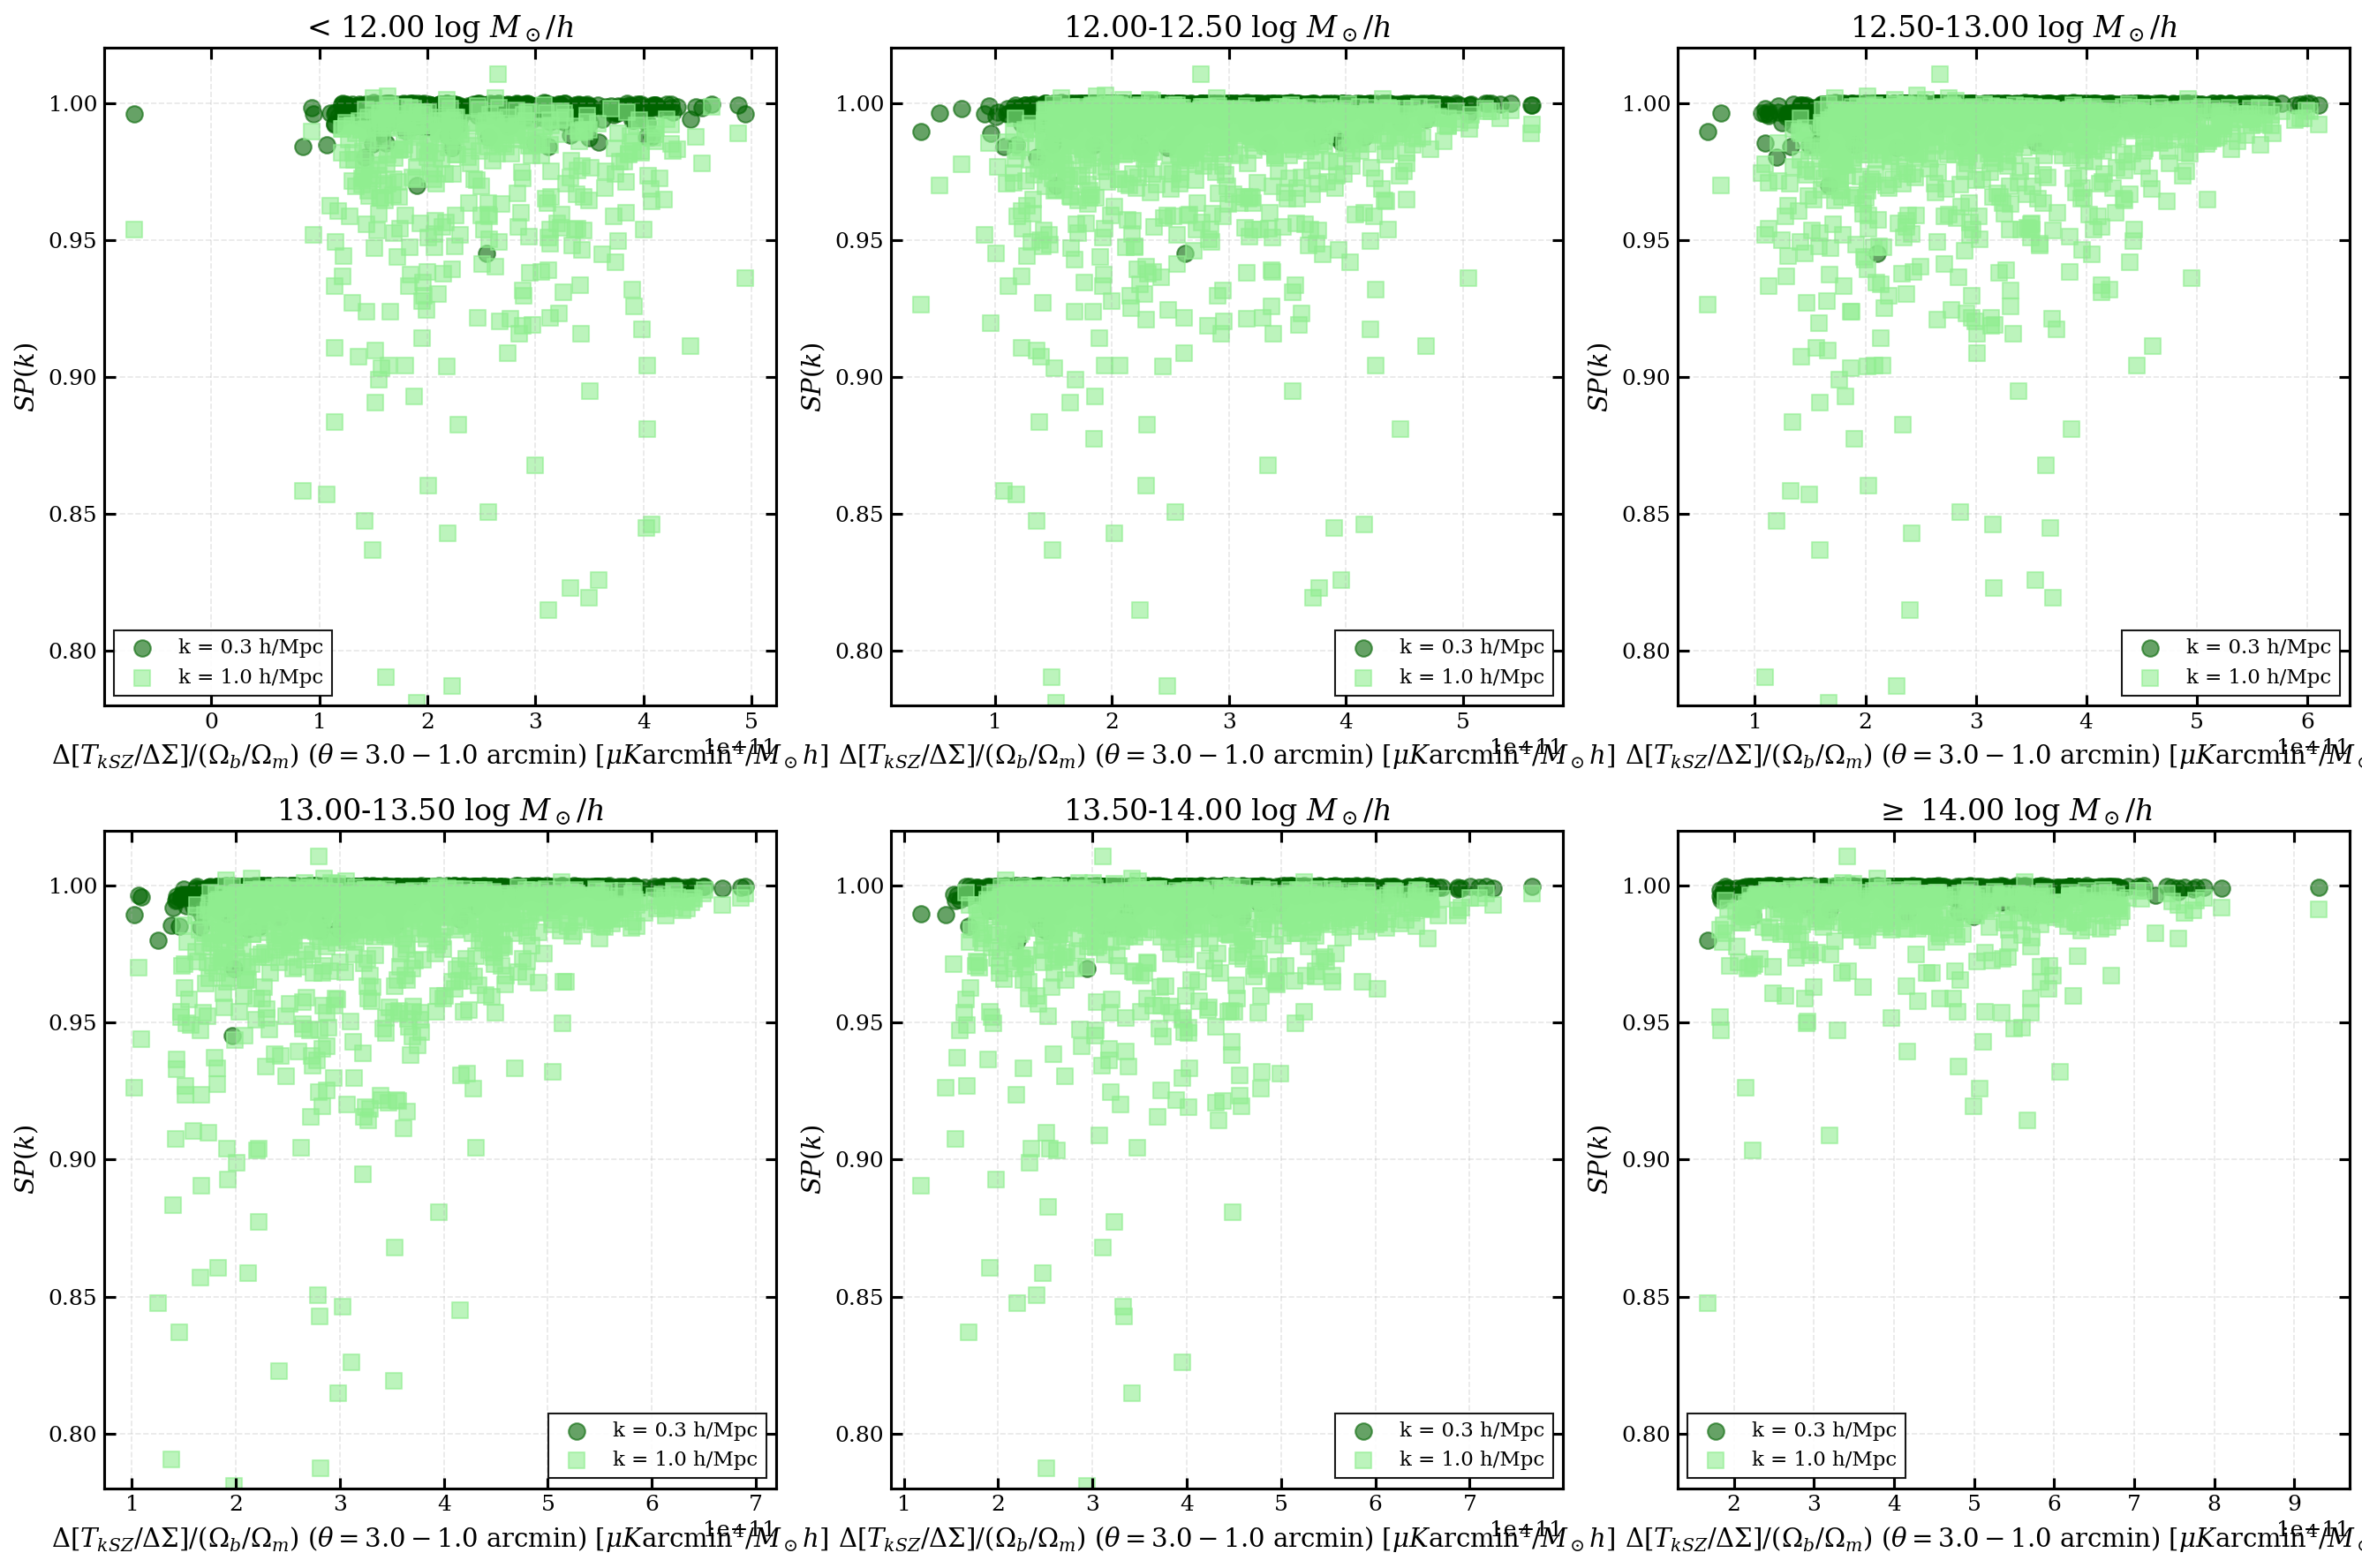

In [38]:
plot_ratio_vs_suppression(k_value1=0.3, k_value2=1.0, theta_arcmin_value1=1.0, theta_arcmin_value2=3.0)

k=0.3 closest to k=0.302, k=1 closest to k=1.062
Using θ=3.0 arcmin


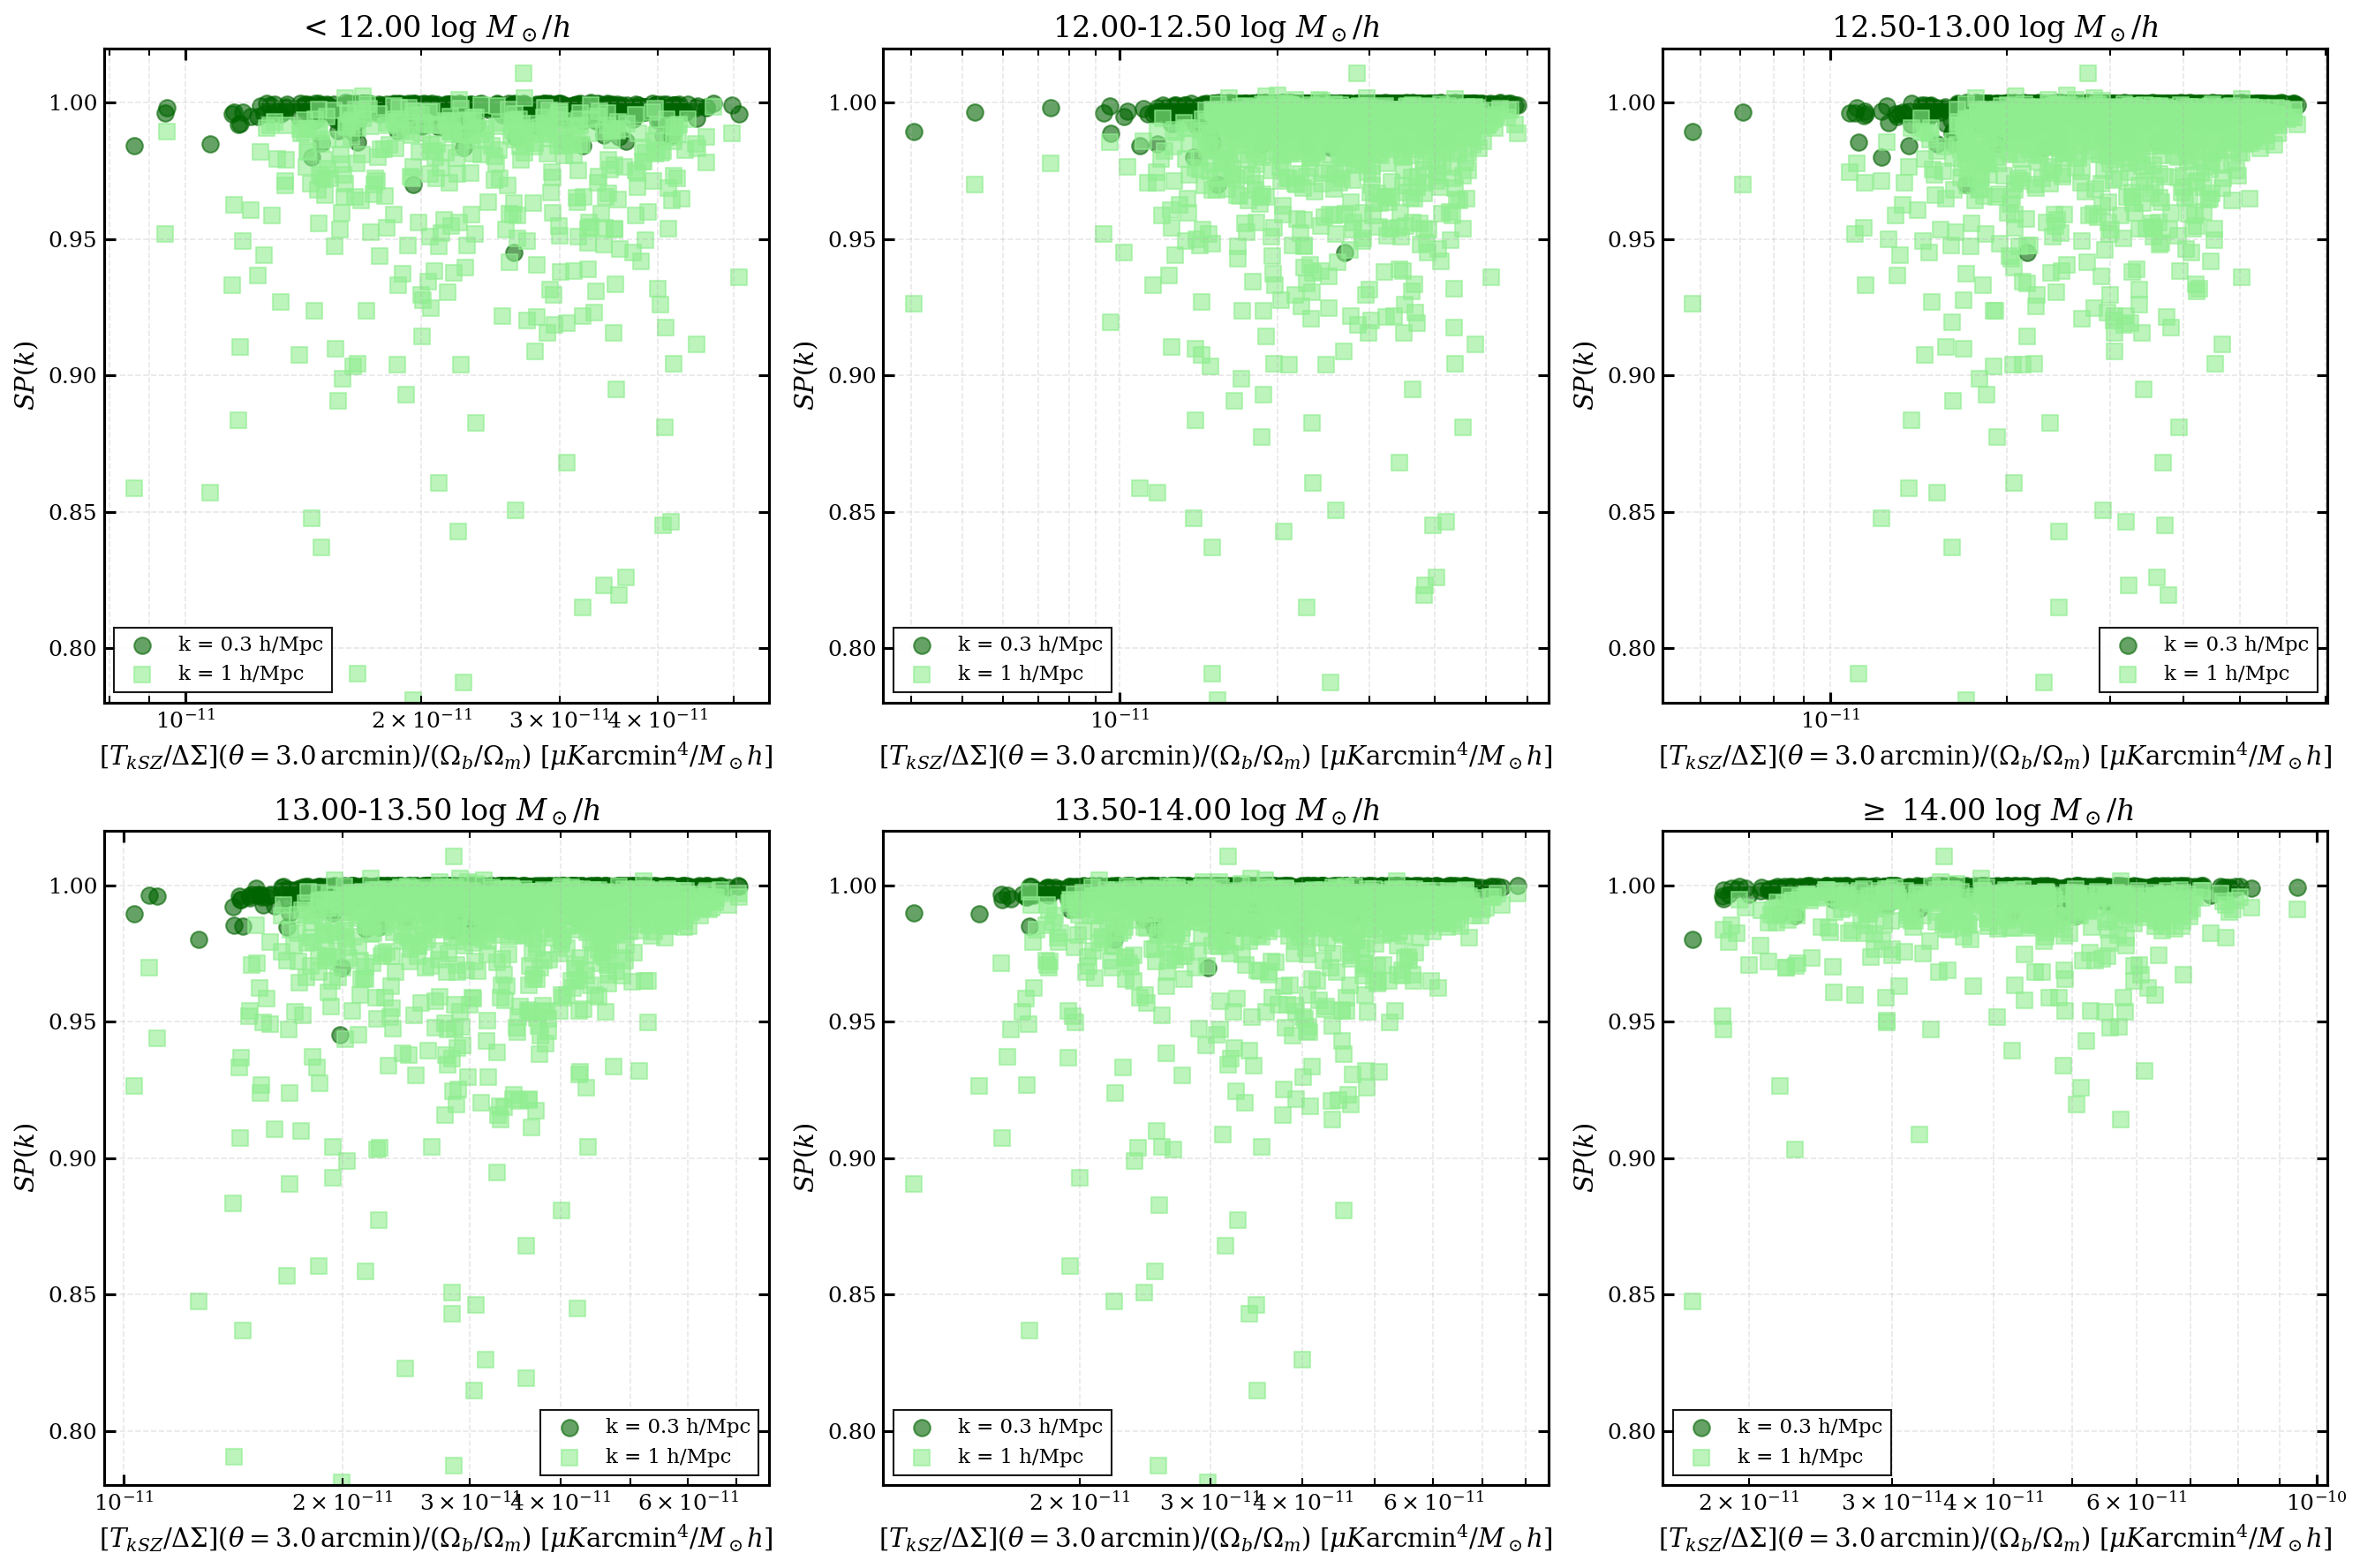

In [39]:
plot_ratio_vs_suppression(k_value1=0.3, k_value2=1, theta_arcmin_value1=3.0)

k=0.3 closest to k=0.302, k=1 closest to k=1.062
Using θ difference: 3.0 - 0.1 arcmin


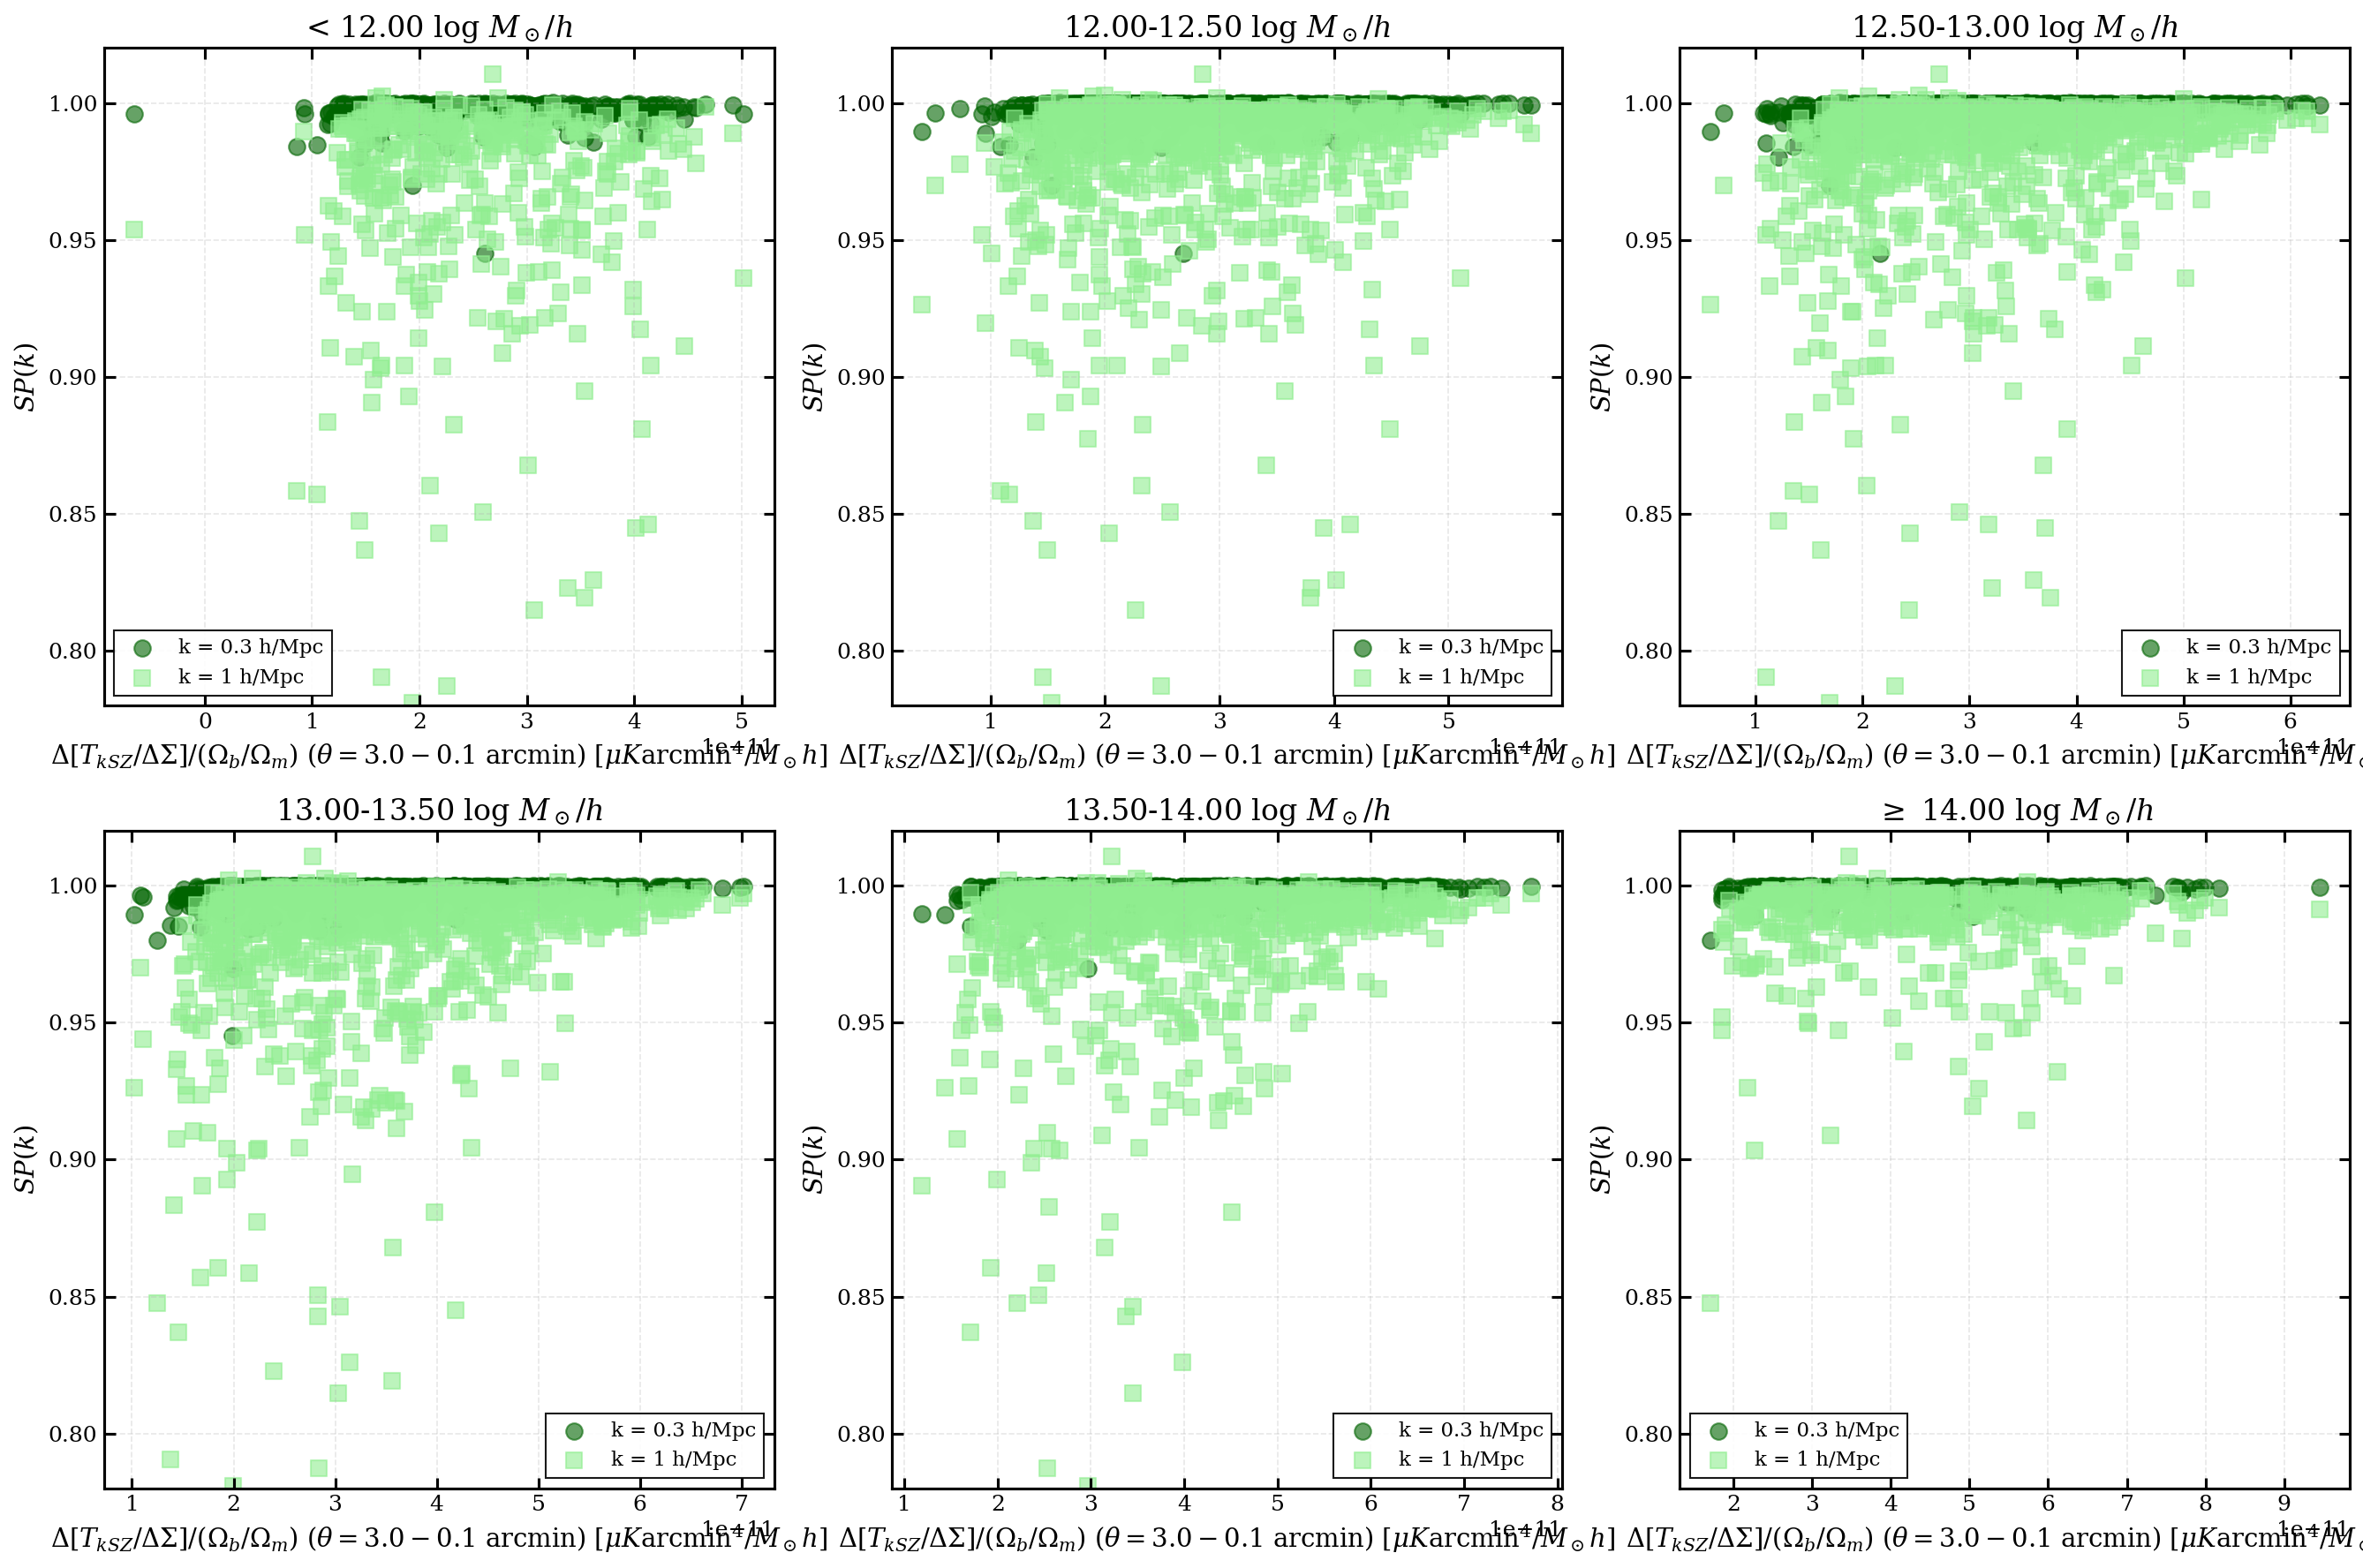

In [40]:
plot_ratio_vs_suppression(k_value1=0.3, k_value2=1, theta_arcmin_value1=0.1, theta_arcmin_value2=3)

In [54]:
r1_mpch_all_sims[0]

array([ 0.05701506,  0.1995527 ,  0.34209034,  0.48462799,  0.62716563,
        0.76970327,  0.91224092,  1.05477856,  1.1973162 ,  1.33985385,
        1.48239149,  1.62492913,  1.76746678,  1.91000442,  2.05254206,
        2.36587616,  2.72704278,  3.14334386,  3.62319606,  4.17630086,
        4.81384076,  5.54870534,  6.39575185,  7.37210559,  8.49750619,
        9.79470662, 11.28993325, 13.01341611, 15.        ])

In [55]:
r1_mpch_all_sims[15]

array([ 0.05737159,  0.20080057,  0.34422956,  0.48765854,  0.63108752,
        0.7745165 ,  0.91794548,  1.06137446,  1.20480345,  1.34823243,
        1.49166141,  1.63509039,  1.77851937,  1.92194836,  2.06537734,
        2.379611  ,  2.74165326,  3.15877789,  3.63936531,  4.19307095,
        4.8310193 ,  5.56602731,  6.412862  ,  7.38853704,  8.51265467,
        9.80779944, 11.29999204, 13.01921198, 15.        ])

In [56]:
r1_arcmin_all_sims[15]

array([ 0.16666667,  0.58333333,  1.        ,  1.41666667,  1.83333333,
        2.25      ,  2.66666667,  3.08333333,  3.5       ,  3.91666667,
        4.33333333,  4.75      ,  5.16666667,  5.58333333,  6.        ,
        6.91286079,  7.96460738,  9.17637035, 10.57249513, 12.18103117,
       14.03429546, 16.1695218 , 18.62960888, 21.46398212, 24.72958674,
       28.49203175, 32.82690819, 37.82130774, 43.57557255])